In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from numpy import exp as exp
import scipy.io as sio

# Creation of folder for plots saving in png files

In [2]:
import os
folder_name = "figs_TMEM165"
if not os.path.exists(folder_name):
    os.makedirs(folder_name)

# Na,K-ATPase surface approximation

In [3]:
#Array export and creating

CK = np.arange(0, 0.110001, 0.005) #23
CNa = np.arange(0, 0.50001, 0.025) #21
psi = np.arange(-80, 261, 20) #18
flux_psi = sio.loadmat('flux_psi.mat')['flux_psi']
kflux_psi = sio.loadmat('kflux_psi.mat')['kflux_psi']
naflux_psi = sio.loadmat('naflux_psi.mat')['naflux_psi']

In [4]:
def interpolate_flux(K, Na, Psi, CK=CK, CNa=CNa, psi=psi, flux_psi=naflux_psi):
    def find_nearest_indices(value, array):
        idx = np.searchsorted(array, value)
        idx = np.clip(idx, 1, len(array) - 1)
        return idx - 1, idx

    def interpolate_1d(value, array, idx1, idx2):
        x1, x2 = array[idx1], array[idx2]
        return (value - x1) / (x2 - x1)

    k_idx1, k_idx2 = find_nearest_indices(K, CK)
    na_idx1, na_idx2 = find_nearest_indices(Na, CNa)
    psi_idx1, psi_idx2 = find_nearest_indices(Psi, psi)

    k_ratio = interpolate_1d(K, CK, k_idx1, k_idx2)
    na_ratio = interpolate_1d(Na, CNa, na_idx1, na_idx2)
    psi_ratio = interpolate_1d(Psi, psi, psi_idx1, psi_idx2)

    c00 = flux_psi[k_idx1, na_idx1, psi_idx1] * (1 - k_ratio) + flux_psi[k_idx2, na_idx1, psi_idx1] * k_ratio
    c01 = flux_psi[k_idx1, na_idx1, psi_idx2] * (1 - k_ratio) + flux_psi[k_idx2, na_idx1, psi_idx2] * k_ratio
    c10 = flux_psi[k_idx1, na_idx2, psi_idx1] * (1 - k_ratio) + flux_psi[k_idx2, na_idx2, psi_idx1] * k_ratio
    c11 = flux_psi[k_idx1, na_idx2, psi_idx2] * (1 - k_ratio) + flux_psi[k_idx2, na_idx2, psi_idx2] * k_ratio

    c0 = c00 * (1 - na_ratio) + c10 * na_ratio
    c1 = c01 * (1 - na_ratio) + c11 * na_ratio

    return c0 * (1 - psi_ratio) + c1 * psi_ratio

In [5]:
x = np.outer(np.linspace(0.01, 0.100, 300), np.ones(300))
y = np.outer(np.linspace(-100, 200, 300), np.ones(300)).T
z = np.vectorize(interpolate_flux)(x, 0.06 , y)

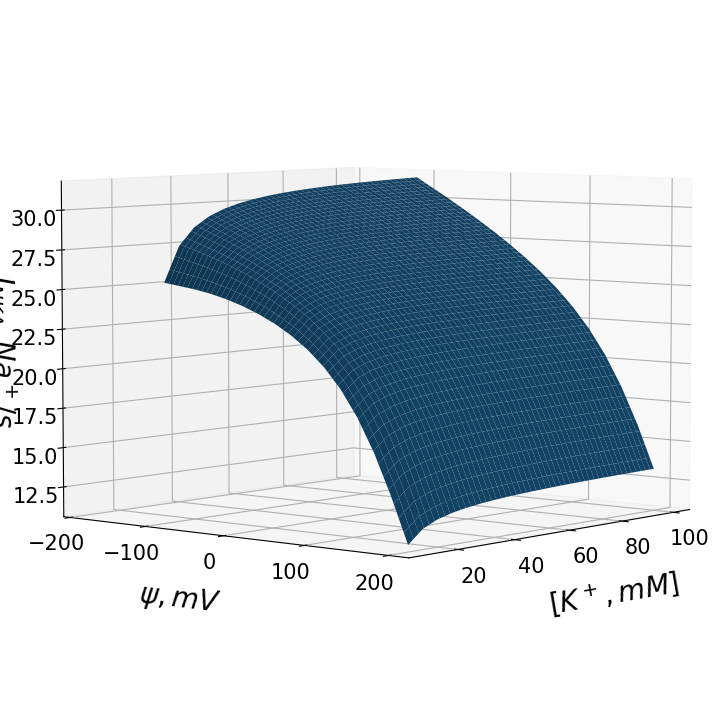

In [6]:
# Creating figure
fig = plt.figure(figsize = (14, 9), dpi = 100)
ax = plt.axes(projection ='3d')
ax.invert_xaxis()
# Creating plot
ax.plot_surface(x*1000, y, z)
ax.view_init(5, 40)
plt.xlabel(r'$[K^+, mM]$', fontsize = 20, labelpad=20)

plt.ylabel(r'$\psi, mV$', fontsize = 20, labelpad=20)
plt.xticks(fontsize = 15)
y_ticks = np.arange(-200, 201, 100)
plt.yticks(y_ticks, fontsize=15)
font = {'size': 15}
ax.tick_params('z', labelsize=font['size'])
#make zlabel another font 'Times new roman'ArithmeticError
z_label = ax.set_zlabel(r'$J_{NKA}, Na^+/s$', fontsize=20, rotation=120)


plt.savefig('figs_TMEM165/NKA_surface.png', dpi = 300, bbox_inches='tight') #, bbox_inches='tight'


# show plot
plt.show()

# vATPase function

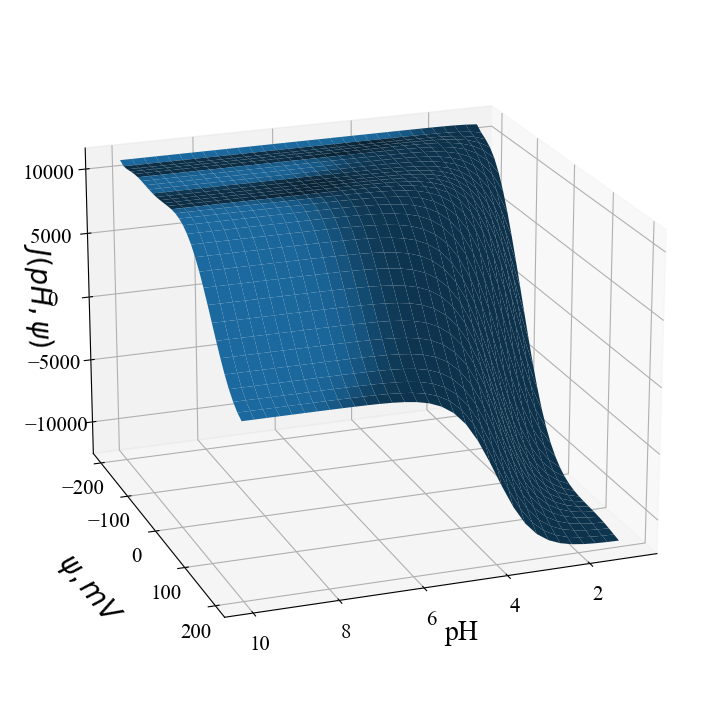

In [7]:
# @jit
def J_v(pH_L, psi):
    
    psi_start, psi_end = -300, 300
    pH_start, pH_end = 0, 9
    
    if (pH_L < pH_start):
        pH_L = pH_start
    elif (pH_L > pH_end):
        pH_L = pH_end
    
    if (psi < psi_start):
        psi = psi_start
    elif (psi > psi_end):
        psi = psi_end
    
    p_a = 3.3654e-24*psi**10+-1.72718633e-21*psi**9+-1.88006118e-19*psi**8+1.84428806e-16*psi**7+1.14875767e-15*psi**6+-7.86180209e-12*psi**5+8.73621142e-11*psi**4+1.38612359e-07*psi**3+4.02706504e-06*psi**2+-0.000921991562*psi**1+0.892742811*psi**0
    p_b = -0.01183303*psi**1+-1.74410965*psi**0
    p_c = 1.97927106e-17*psi**8+-8.11163955e-15*psi**7+-1.41331765e-12*psi**6+7.37414295e-10*psi**5+2.69242151e-08*psi**4+-1.47727446e-05*psi**3+-0.0018809272*psi**2+0.0294192901*psi**1+122.27226*psi**0
    p_d = 3.32575786e-13*psi**6+-3.43339599e-11*psi**5+-5.76545216e-08*psi**4+7.89631331e-06*psi**3+0.00138326473*psi**2+0.11950506*psi**1+1.50734239*psi**0
    
    
    J = np.tanh(p_a*pH_L + p_b)*p_c-p_d
    return J*550/6

x = np.outer(np.linspace(1, 10, 32), np.ones(32))
y = np.outer(np.linspace(-200, 200, 32), np.ones(32)).T
z = np.vectorize(J_v)(x, y)



 
# Creating figure
fig = plt.figure(figsize = (14, 9))
plt.rc('font', family='Times New Roman')
ax = plt.axes(projection ='3d')

# Creating plot
ax.plot_surface(x, y, z)
ax.view_init(20, 70)
plt.xlabel(r'pH', fontsize = 20)

plt.ylabel(r'$\psi, mV$', fontsize = 20, labelpad=20)
plt.xticks(fontsize = 15)
y_ticks = np.arange(-200, 201, 100)
plt.yticks(y_ticks, fontsize=15)
font = {'size': 15}
ax.tick_params('z', labelsize=font['size'])
#make zlabel another font 'Times new roman'ArithmeticError
ax.zaxis.set_tick_params(pad=10) 
z_label = ax.set_zlabel(r'$J(pH, \psi)$', fontsize=20, rotation=60)
plt.savefig('figs_TMEM165/Approx_vATPase.png')



# show plot
plt.show()

## TMEM165 surface

C:\Users\yfal\AppData\Local\Temp\ipykernel_15404\3722995857.py:66: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


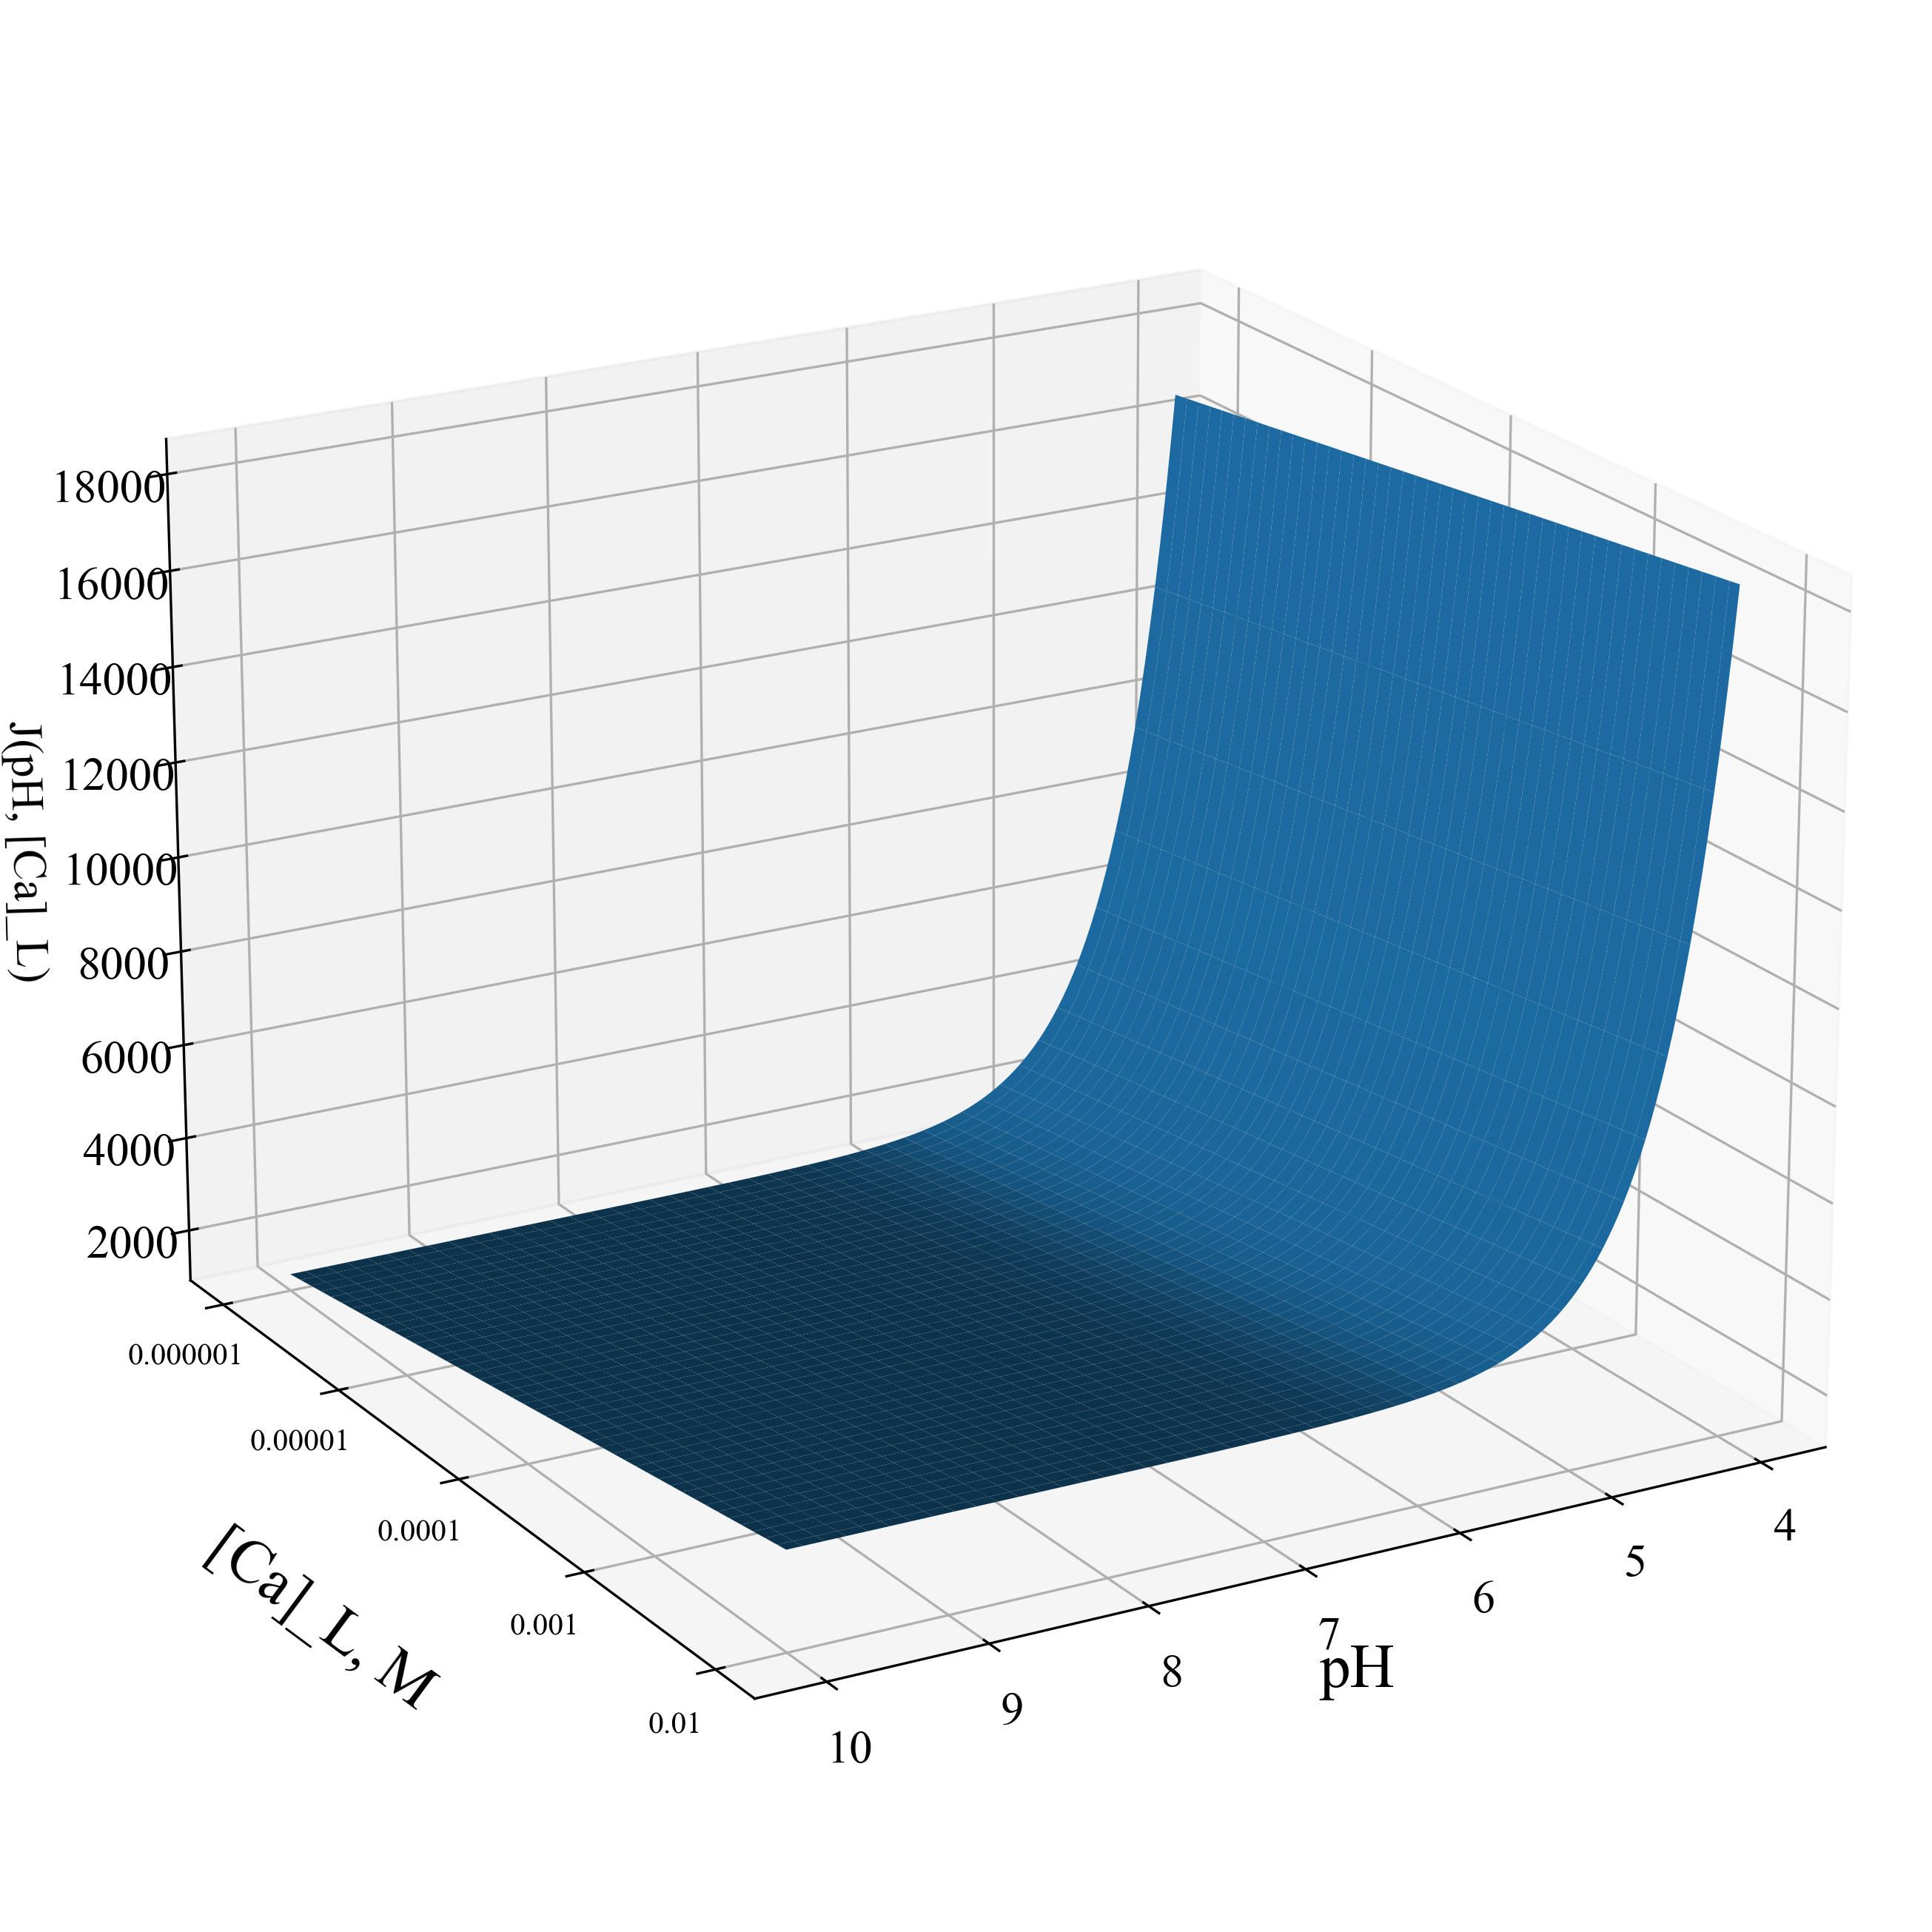

In [8]:
def J_TMEM165_surface(pH_L0, Ca_F_L0, pH_C0, Ca_F_C0, psi):
    R = 0.34
    S = S = 4*3.1416*abs(R)**2*1e-8
    RTF = 26.72 
    NA = 6.02e+23
    TMEM165_Ca = 1       # Calcium stoichiometry of TMEM165
    TMEM165_H = 3        # Proton stoichiometry of TMEM165
    if (abs(psi) > 300):
        psi = np.sign(psi)*300
    if (abs(psi) > 0.01):
        gg      =  psi / (1 - exp (- psi / RTF)) / RTF
        gg_Ca   = 2*psi/(1-exp(-2*psi/RTF))/RTF

    else: 
        gg      =  1 / 1 - (psi / RTF)/2 + (psi / RTF)**2/6 - (psi / RTF)**3 / 24 + (psi / RTF) ** 4 / 120
        gg_Ca   = 1/(1 - (psi/RTF) + (2/3)*(psi/RTF)**2 - (1/3)*(psi/RTF)**3 +(2/15)*(psi/RTF)**4)
    J_Ca_TMEM165 = S*(10**(-pH_C0)*exp(-psi/RTF)-10**(-pH_L0))*gg*NA/1000-2*((TMEM165_H - 2*TMEM165_Ca)*psi + RTF*(TMEM165_Ca/2*np.log(Ca_F_L0/Ca_F_C0)))*1e6
    N_TMEM165 = 0.0000035*2
    
    J = -J_Ca_TMEM165*N_TMEM165
    return J


x = np.outer(np.linspace(4, 10, 180), np.ones(180))



Y_linear = np.logspace(-6, -2, 180)  # Y from 1 to 100 (log scale)  
Y_log = np.log10(Y_linear)  
 


y = np.outer(Y_log, np.ones(180)).T
z = np.vectorize(J_TMEM165_surface)(x, Y_linear, 7.2, 1e-07, 60)



 
# Creating figure
fig = plt.figure(figsize = (15, 10), dpi = 300)
plt.rc('font', family='Times New Roman')
ax = plt.axes(projection ='3d')

# Creating plot
ax.plot_surface(x, Y_log, z)
ax.view_init(20, 60)
plt.xlabel(r'pH', fontsize = 20)
ax.set_yticks([-6, -5, -4, -3, -2])  
ax.set_yticklabels(['0.000001', '0.00001', '0.0001', '0.001', '0.01'])  

plt.ylabel('[Ca]_L, M', fontsize = 20, labelpad=20)
plt.xticks(fontsize = 15)
# y_ticks = np.arange(-200, 201, 100)
# plt.yticks(y_ticks, fontsize=15)
# ax.set_yscale('log')

font = {'size': 15}
ax.tick_params('z', labelsize=font['size'])
#make zlabel another font 'Times new roman'ArithmeticError
z_label = ax.set_zlabel('J(pH, [Ca]_L)', fontsize=15, rotation=60, labelpad=10)

# Set logarithmic scale for y-axis

# Adjust subplot to prevent label cutoff
plt.subplots_adjust(left=0.1, right=0.95, top=0.95, bottom=0.1)
plt.tight_layout()

plt.savefig('figs_TMEM165/Approx_tmem165.png', bbox_inches='tight')


# show plot
plt.show()

# Constants and initial values

In [9]:
# Physical constants
F = 96485      #[C] Na*e
NA = 6.02e+23   # Avogadro constant [Particles/mol]
RTF = 26.72        #RT/F [mV]} 

# Lysosome sizes
init_R = 0.34            #organelle radius [microns]
init_V = (4/3*3.1416*init_R**3*1e-12)/1000 #{surface area [cm**2]}
init_S = 4*3.1416*init_R**2*1e-8 #{lysosome volume  [liters]}

# cytosolic initial concentrations and pH
Ca_C = 1e-07      #[M]
Cl_C = 0.05      #[M]
Na_C = 0.015      #[M]
K_C = 0.145      #[M]
pH_C = 7.2     



# Selective ion transporters settings
# Stoichiometries of ion transporters
TMEM165_Ca = 1       # Calcium stoichiometry of TMEM165
TMEM165_H = 3        # Proton stoichiometry of TMEM165
CLC_Cl = 2       # Chloride stoichiometry of ClC-7
CLC_H = 1        # Proton stoichiometry of ClC-7

# Activities of ion transporters

N_CLC = 50      #Number of ClC-7 []
N_TPC = 38 #by patch 
N_TMEM = 1



init_Aeff = 0.3 #Initial effective activity of ClC-7
q = 2.2         # Coefficient for ClC-7
r = 0.1         #Deactivation to activation ratio for ClC-7
tau_act = 1     #Activation time for ClC-7 [s]
tau_deact = 0.25     #Activation time for ClC-7  for ClC-7 [s]
N_VATP = 6     #Number of vATPases []
N_NKA = 13000    #"Activity" of NKA []
p = 3.88e-12     #TRPML1 coefficient []

# Lysosome membrane permeabilities
P_Ca = 1.49e-7      #[ion*cm/s]
P_Cl = 1.2e-5       #[ion*cm/s]
P_H = 6e-05      #[ion*cm/s]
P_K = 7.1e-7 *1.6     #[ion*cm/s]
P_Na = 9.6e-7*686/1000      #[ion*cm/s]
Pw = 0.054e-2   #water permeability

# lysosome physical properties
beta_pH = 0.04      #[M/pH] Proton buffering capacity
cap = 1.45267584e-14      #[Farad] 
cap_0 = 1e-06      #[F/cm^2] membrane Bilayer capacitance 

# lysosome initial concentrations, potential and pH
init_Ca_F = 0.0005      #[M]
init_Ca_T = 0.005      #[M]
init_Cl = 0.1  #[M]
init_pH = 4.7
init_H = 0.05     #[M]
init_K = 0.07   #[M]
init_Na = 0.010   #[M]

psi_in = 0       #potential [mV]
psi_out = -50    #potential [mV]
# B is the concentration of Donnan particles, 
B = init_K+init_Na+init_H-init_Cl  + init_Ca_T*2 - cap/F/init_V*(psi_in - psi_out) 


      


# Osmolarities
Oc = 0.291
oh =  0.73
ok =  0.73
ona = 0.73
ocl = 0.73
Q = init_V*(Oc - (oh*10**(-init_pH) + ok*init_K + ona*init_Na + ocl*init_Cl))

# Derivatives

In [10]:
# @jit
def derivatives(X, t, stress = 'No', ind_vATPase = 1):
    '''
    compute derivatives of X wrt time
    '''
    Aeff, NH, pH, NK, NNa, NCl, NCa_T, NCa_F, R = X

    N_VATP = 7
    p = 3.88e-12

    P_Ca = 1.49e-7      #[ion*cm/s]
    P_Cl = 1.2e-5       #[ion*cm/s]
    P_H = 6.2e-05      #[ion*cm/s]
    P_K = 7.1e-7 *1.6     #[ion*cm/s]
    P_Na = 9.6e-7*686/1000      #[ion*cm/s]
    Pw = 0.054e-2   #water permeability

    pure_basefication = 0


    if stress == 'Permeabilization10':
        if ((t>800) and (t<1500)):
            n_per = 10
            P_Ca = 1.49e-7*686/1000 *n_per        #[ion*cm/s]
            P_Cl = 1.2e-5*n_per       #[ion*cm/s]
            P_H = 6e-05*n_per        #[ion*cm/s]
            P_K = 7.1e-7*1.6 *n_per        #[ion*cm/s]
            P_Na = 9.6e-7*n_per   
            Pw = 0.054e-2*n_per  
        
        else:
            P_Ca = 1.49e-7      #[ion*cm/s]
            P_Cl = 1.2e-5       #[ion*cm/s]
            P_H = 6.2e-05      #[ion*cm/s]
            P_K = 7.1e-7 *1.6     #[ion*cm/s]
            P_Na = 9.6e-7*686/1000      #[ion*cm/s]
            Pw = 0.054e-2 



    if stress == 'Permeabilization100':
        if ((t>800) and (t<1500)):
            n_per = 100
            P_Ca = 1.49e-7*686/1000 *n_per        #[ion*cm/s]
            P_Cl = 1.2e-5*n_per       #[ion*cm/s]
            P_H = 6e-05*n_per        #[ion*cm/s]
            P_K = 7.1e-7*1.6 *n_per        #[ion*cm/s]
            P_Na = 9.6e-7*n_per   
            Pw = 0.054e-2*n_per  
        
        else:
            P_Ca = 1.49e-7        #[ion*cm/s]
            P_Cl = 1.2e-5       #[ion*cm/s]
            P_H = 6e-05      #[ion*cm/s]
            P_K = 7.1e-7      #[ion*cm/s]
            P_Na = 9.6e-7 
            Pw = 0.054e-2


        
        
    if stress == 'Ca_v':
        if (t>2000):
            N_VATP = 1
        else:
            N_VATP = 7

    if stress == 'Ca_al':
        pure_basefication = int((t>=2000))*5.12e4
     
    
    V = (4/3*3.1416*abs(R)**3*1e-12)/1000
    S = 4*3.1416*abs(R)**2*1e-8


    #Luminal Concentrations
    H = NH/V/NA
    K = NK/V/NA
    Na = NNa/V/NA
    Cl = NCl/V/NA
    Ca_F = NCa_F/V/NA
    Ca_T = NCa_T/V/NA
    r = Ca_F/Ca_T

    
    #membrane potential
#     psi = (F/cap)*init_V*(H + K + Na - Cl + 2*Ca_T - B)
    psi = (F/cap)*(V*(H + K + Na - Cl + 2*Ca_T) - B*init_V)


#      Modified Cytoplasmic Surface Concentrations
    pH_C0   = (pH_C+psi_out/(RTF*2.3))
    K_C0    = K_C*exp(-psi_out/RTF)
    Na_C0   = Na_C*exp(-psi_out/RTF) 
    Cl_C0   = Cl_C*exp(psi_out/RTF) 
    Ca_F_C0 = Ca_C*exp(-2*psi_out/RTF) 
    
#     Modified Luminal Surface Concentrations
    pH_L0   = (pH+psi_in/(RTF*2.3))
    K_L0    = K*exp(-psi_in/RTF)
    Na_L0   = Na*exp(-psi_in/RTF) 
    Cl_L0   = Cl*exp(psi_in/RTF) 
    Ca_F_L0 = Ca_F*exp(-2*psi_in/RTF) 

    delta_pH    = pH_C0-pH_L0;  

#     Treatment of singular terms for passive ion flux
    if (abs(psi) > 300):
        psi = np.sign(psi)*300
    if (abs(psi) > 0.01):
        gg      =  psi / (1 - exp (- psi / RTF)) / RTF
        gg_Ca   = 2*psi/(1-exp(-2*psi/RTF))/RTF

    else: 
        gg      =  1 / 1 - (psi / RTF)/2 + (psi / RTF)**2/6 - (psi / RTF)**3 / 24 + (psi / RTF) ** 4 / 120
        gg_Ca   = 1/(1 - (psi/RTF) + (2/3)*(psi/RTF)**2 - (1/3)*(psi/RTF)**3 +(2/15)*(psi/RTF)**4)


        

    # vAPTase
    J_VATPASE  = N_VATP * J_v(pH, psi) * ind_vATPase


        # ClC-7 Antiporter {H out, Cl in}
    CLC_mu      = (CLC_H + CLC_Cl)*psi + RTF*(CLC_H*2.3*delta_pH + CLC_Cl*np.log(Cl_C0/Cl_L0))
    
    #     Switching function   
    x = 0.5 + 0.5*np.tanh((CLC_mu + 250)/75); 
    # Activity
    A = 0.3*x + 1.5E-5*(1-x)*CLC_mu**2;
    
    if (A < Aeff):
        tau = tau_deact
    else:
        tau = tau_act
        
    J_CLC    = N_CLC*Aeff*CLC_mu 
    
    
    
    
    
    
#      Passive flux [ion/s]
    J_H = P_H*S*(10**(-pH_C0)*exp(-psi/RTF)-10**(-pH_L0))*gg*NA/1000
    J_K = P_K*S*(K_C0*exp(-psi/RTF)-K_L0)*gg*NA/1000 #this is TMEM
    J_Na = P_Na*S*(Na_C0*exp(-psi/RTF)-Na_L0)*gg*NA/1000
    J_Cl_unc = P_Cl*S*(Cl_C0-Cl_L0*exp(-psi/RTF))*gg*NA/1000
    J_Ca = P_Ca*S*(Ca_F_C0*exp(-2*psi/RTF)-Ca_F_L0)*gg_Ca*NA/1000
    


    
    #water flux
    J_w = Pw*S*(oh*10**(-pH) + ok*K + ona*Na + ocl*Cl + Q/V - Oc)
    
#     TRPML1 channel
    y = 0.5 - 0.5*np.tanh(psi + 40)
    P_trpml1 = p*(y*abs(psi) + (1-y)*(abs (psi + 40)**3)/(pH_L0**q))
    J_Ca_trpml1 = P_trpml1*S*(Ca_F_C0*exp(-2*psi/RTF)-Ca_F_L0)*gg_Ca*NA/1000

  


    #   TPC {Na out}
    
    xh = 6.7e3*exp(-0.9*pH) - 15
    k = 11.3*pH**2 - 116.5*pH + 325.3
    P_TPC = 1/(1+exp((xh-psi)/k))
    J_TPC = N_TPC*P_TPC*S*(Na_C0*exp(-psi/RTF)-Na_L0)*gg*NA/1000


    if stress == 'Fast_vastpase_stress':
        if (t>500 and t<850):
            J_VATPASE = 0

    if stress == 'Fast_swelling':
        if (t>500 and t<850):
            J_w += 1e-13
            
            
    J_Ca_TMEM165 = S*(10**(-pH_C0)*exp(-psi/RTF)-10**(-pH_L0))*gg*NA/1000-2*((TMEM165_H - 2*TMEM165_Ca)*psi + RTF*(TMEM165_Ca/2*np.log(Ca_F_L0/Ca_F_C0)))*1e6
    N_TMEM165 = 0.0000086



    if NCa_T + (J_Ca - TMEM165_Ca*J_Ca_TMEM165*N_TMEM165 + J_Ca_trpml1)<=0:
        J_Ca = 0
        J_Ca_trpml1 = 0
        J_Ca_TMEM165 = 0
        print('Ca concentration is too close to negative')





    dxdt = [(1/tau)*(A - Aeff),
        (J_H + (J_VATPASE) - (CLC_H*J_CLC) + (TMEM165_H*J_Ca_TMEM165*N_TMEM165) - pure_basefication), 
           (-(J_H + (J_VATPASE) - (CLC_H*J_CLC) + (TMEM165_H*J_Ca_TMEM165*N_TMEM165) - pure_basefication)/V/NA)/beta_pH,
           (J_K),
           (J_Na + J_TPC),
           (J_Cl_unc + (CLC_Cl*J_CLC)),
           (J_Ca - TMEM165_Ca*J_Ca_TMEM165*N_TMEM165 + J_Ca_trpml1),
           (J_Ca - TMEM165_Ca*J_Ca_TMEM165*N_TMEM165 + J_Ca_trpml1)*r, 
           J_w/(1000*55)/(4*np.pi*(R/1e5)**2)*1e5]

    return dxdt

In [11]:
init_NH = init_H*init_V*NA;      #[ions]
init_NK = init_K*init_V*NA;       
init_NNa = init_Na*init_V*NA;    
init_NCl = init_Cl*init_V*NA;     
init_NCa_T = init_Ca_T*init_V*NA; 
init_NCa_F = init_Ca_F*init_V*NA; 

X0 = [init_Aeff, init_NH, init_pH, init_NK, init_NNa, init_NCl, init_NCa_T, init_NCa_F, init_R]

# Plots

In [12]:
def set_plot_font_params():
    """
    Set the font parameters for all plots in the Matplotlib instance.
    """
    # Set the font family and style
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['Times new roman']
    plt.rcParams['font.style'] = 'normal'

    # Set the font sizes
    plt.rcParams['axes.labelsize'] = 30
    plt.rcParams['xtick.labelsize'] = 20
    plt.rcParams['ytick.labelsize'] = 20
    plt.rcParams['legend.fontsize'] = 20
set_plot_font_params()

In [13]:
def V_arr_def(solution):
    V_arr = (4/3*3.1416*solution[:, 8]**3*1e-12)/1000
    return V_arr

def Psi_arr_def(solution, V_arr):
    psi_arr = (F/cap)*(V_arr*(solution[:, 1]/V_arr/NA + solution[:, 3]/V_arr/NA + 
                              solution[:, 4]/V_arr/NA - solution[:, 5]/V_arr/NA + 
                              2*solution[:, 6]/V_arr/NA) 
                       - B*init_V)
    return psi_arr
    
def J_w_arr_def(solution, V_arr):
    J_w_arr = Pw*4*3.1416*abs(solution[:, 8])**2*1e-8*(oh*10**(-solution[:, 2]) + ok*solution[:, 3]/V_arr/NA + ona*solution[:, 4]/V_arr/NA + ocl*solution[:, 5]/V_arr/NA + Q/V_arr - Oc)
    return J_w_arr*1000*NA





In [14]:
def plot_solution_concentrations(t, solution, solution_stat, V_arr, V_arr_stat, 
                                 x_text = 0.36, legend_loc=[0.55, 0.6], save = False, save_solder = 'figs_TMEM165', save_name = '', show_Ca = False,
                                 show_H = False):
    fig, ax = plt.subplots(figsize=(6, 6), dpi=100)
    ca_conc = solution[:, 7] / V_arr / NA*1000
    cl_conc = solution[:, 5] / V_arr / NA*1000
    k_conc = solution[:, 3] / V_arr / NA*1000
    na_conc = solution[:, 4] / V_arr / NA*1000
    h_conc = solution[:, 1] / V_arr / NA*1000


    ca_stat = solution_stat[:, 7][-1] / V_arr_stat[-1] / NA*1000
    cl_stat = solution_stat[:, 5][-1] / V_arr_stat[-1] / NA*1000
    k_stat = solution_stat[:, 3][-1] / V_arr_stat[-1] / NA*1000
    na_stat = solution_stat[:, 4][-1] / V_arr_stat[-1] / NA*1000
    h_stat = solution_stat[:, 1][-1] / V_arr_stat[-1] / NA*1000

    t = t/3600
    # Plot the concentrations
    ax.plot(t, cl_conc, 'b', label='Cl(t)')
    ax.plot(t, k_conc, 'r', label='K(t)')
    ax.plot(t, na_conc, 'g', label='Na(t)')

    ax.set_ylabel('Ions concentrations, mM', fontsize=30, labelpad=10)
    ax.set_xlabel('Time, h', fontsize=30)
    ax.tick_params(axis='both', labelsize=20)
#     ax.set_adjustable('box')
    # plt.xlim(0, 3.5)
    # Extend the horizontal lines beyond the plot area
    ax.axhline(cl_stat, 0, 1, color = 'b', clip_on=False, linestyle='dashed', alpha = 0.4)
    ax.axhline(k_stat, 0, 1, color = 'r', clip_on=False, linestyle='dashed', alpha = 0.4)
    ax.axhline(na_stat, 0, 1, color = 'g', clip_on=False, linestyle='dashed', alpha = 0.4)



    ax.text(x=x_text, y=cl_stat*1.02, s=round(cl_stat, 1), fontsize=18, color='b')
    ax.text(x=x_text, y=k_stat*1.015, s=round(k_stat, 1), fontsize=18, color='r')
    ax.text(x=x_text, y=na_stat*1.01, s=round(na_stat, 1), fontsize=18, color='g')

    if show_Ca:
        ax.plot(t, ca_conc, 'purple', label='Ca(t)')
        ax.axhline(ca_stat, 0, 1, color = 'purple', clip_on=False, linestyle='dashed', alpha = 0.4)
        ax.text(x=x_text, y=ca_stat*1.01, s=round(ca_stat, 1), fontsize=18, color='purple')
    if show_H:
        ax.plot(t, h_conc, 'black', label='H(t)')
        ax.axhline(h_stat, 0, 1, color = 'black', clip_on=False, linestyle='dashed', alpha = 0.4)
        ax.text(x=x_text, y=h_stat*1.01, s=round(h_stat, 1), fontsize=18, color='black')
    ax.legend(loc=legend_loc, fontsize=20, frameon=False)

    plt.tight_layout()

    if save:
        plt.savefig(f'{save_solder}/{save_name}_conc.png', dpi = 300, bbox_inches='tight')
    plt.show()



In [15]:
def plot_solution_concentrations_stress(t, solution, solution_stat, V_arr, V_arr_stat, 
                                 x_text = 0.36, legend_loc=[0.55, 0.6], save = False, save_solder = 'figs_TMEM165', save_name = '', show_Ca = False,
                                 show_H = False, stress_time = [80000, 150000], x_stress_text = 0.5, hand_stress = 0, hand_stress_text = [0, 0, 0]):
    fig, ax = plt.subplots(figsize=(6, 6), dpi=100)
    ca_conc = solution[:, 7] / V_arr / NA*1000
    cl_conc = solution[:, 5] / V_arr / NA*1000
    k_conc = solution[:, 3] / V_arr / NA*1000
    na_conc = solution[:, 4] / V_arr / NA*1000
    h_conc = solution[:, 1] / V_arr / NA*1000


    ca_stat = solution_stat[:, 7][-1] / V_arr_stat[-1] / NA*1000
    cl_stat = solution_stat[:, 5][-1] / V_arr_stat[-1] / NA*1000
    k_stat = solution_stat[:, 3][-1] / V_arr_stat[-1] / NA*1000
    na_stat = solution_stat[:, 4][-1] / V_arr_stat[-1] / NA*1000
    h_stat = solution_stat[:, 1][-1] / V_arr_stat[-1] / NA*1000

    t = t/3600
    # Plot the concentrations
    ax.plot(t, cl_conc, 'b', label='Cl(t)')
    ax.plot(t, k_conc, 'r', label='K(t)')
    ax.plot(t, na_conc, 'g', label='Na(t)')

    ax.set_ylabel('Ions concentrations, mM', fontsize=30, labelpad=10)
    ax.set_xlabel('Time, h', fontsize=30)
    ax.tick_params(axis='both', labelsize=20)
#     ax.set_adjustable('box')
    # plt.xlim(0, 3.5)
    # Extend the horizontal lines beyond the plot area
    ax.axhline(cl_stat, 0, 1, color = 'b', clip_on=False, linestyle='dashed', alpha = 0.4)
    ax.axhline(k_stat, 0, 1, color = 'r', clip_on=False, linestyle='dashed', alpha = 0.4)
    ax.axhline(na_stat, 0, 1, color = 'g', clip_on=False, linestyle='dashed', alpha = 0.4)



    ax.text(x=x_text, y=cl_stat*1.02, s=round(cl_stat, 1), fontsize=18, color='b')
    ax.text(x=x_text, y=k_stat*1.015, s=round(k_stat, 1), fontsize=18, color='r')
    ax.text(x=x_text, y=na_stat*1.01, s=round(na_stat, 1), fontsize=18, color='g')

    cl_stress = cl_conc[stress_time[-1]]
    k_stress = k_conc[stress_time[-1]]
    na_stress = na_conc[stress_time[-1]]
    h_stress = h_conc[stress_time[-1]]
    ca_stress = ca_conc[stress_time[-1]]
    


    if hand_stress:
        ax.text(x=x_stress_text, y=hand_stress_text[0], s=round(cl_stress, 1), fontsize=18, color='b')
        ax.text(x=x_stress_text, y=hand_stress_text[1], s=round(k_stress, 1), fontsize=18, color='r')
        ax.text(x=x_stress_text, y=hand_stress_text[2], s=round(na_stress, 1), fontsize=18, color='g')
    else:
        ax.text(x=x_stress_text, y=cl_stress+5, s=round(cl_stress, 1), fontsize=18, color='b')
        ax.text(x=x_stress_text, y=k_stress-6, s=round(k_stress, 1), fontsize=18, color='r')
        ax.text(x=x_stress_text, y=na_stress+5, s=round(na_stress, 1), fontsize=18, color='g')
        print(k_stress)



    if show_Ca:
        ax.plot(t, ca_conc, 'purple', label='Ca(t)')
        ax.axhline(ca_stat, 0, 1, color = 'purple', clip_on=False, linestyle='dashed', alpha = 0.4)
        ax.text(x=x_text, y=ca_stat*1.01, s=round(ca_stat, 2), fontsize=18, color='purple')
        ax.text(x=x_stress_text, y=ca_stress+3, s=round(ca_stress, 3), fontsize=18, color='purple')
    if show_H:
        ax.plot(t, h_conc, 'black', label='H(t)')
        ax.axhline(h_stat, 0, 1, color = 'black', clip_on=False, linestyle='dashed', alpha = 0.4)
        ax.text(x=x_text, y=h_stat*1.01, s=round(h_stat, 1), fontsize=18, color='black')
        ax.text(x=(stress_time[0]+stress_time[1])/2/360000, y=h_stress*1.01, s=round(h_stress, 1), fontsize=18, color='black')
    ax.legend(loc=legend_loc, fontsize=20, frameon=False)
    
    ax.set_ylim(-5, 1.1*max(cl_stress, k_stress, na_stress, cl_conc[-1]))
    # plt.tight_layout()
    

    if save:
        plt.savefig(f'{save_solder}/{save_name}_conc_stress.png', dpi = 300, bbox_inches='tight')
    plt.show()



In [16]:
def plot_solution_pH_psi(t, solution, solution_stat, psi_arr, psi_stat, 
                         set_pHlim = False, pHlim = [0, 0], set_psi_lim = False, psi_lim = [0, 0] ,psi_text = 0.2, 
                         pH_text = 0.8, save = False, save_solder = 'figs_TMEM165', save_name = ''):
    fig, ax1 = plt.subplots(figsize=(6, 6), dpi=100)

    t = t/3600

    # Plot pH
    ax1.plot(t, solution[:, 2], 'black', label='pH$(t)$')
    ax1.set_ylabel(r'pH', fontsize=30, color='black')
    ax1.tick_params(axis='y', colors='black')
    ax1.axhline(solution_stat[:, 2][-1], 0, 1, color = 'black', clip_on=False, linestyle='dashed', alpha = 0.4)
    ax1.text(0.95, pH_text, 'Final pH: {:.3f}'.format(solution_stat[:, 2][-1]), transform=ax1.transAxes, ha='right', va='top', fontsize=20, color='black')

    # Create a second y-axis for psi
    ax2 = ax1.twinx()

    # Plot psi

    ax2.plot(t, psi_arr, 'r', label=r'$\Psi$(t)', alpha=1)  # Set transparency with alpha
    ax2.set_ylabel(r'$\Delta\Psi$, mV', fontsize=30, color='r')
    ax2.tick_params(axis='y', colors='black', labelcolor='red')
    ax2.axhline(psi_stat, 0, 1, color = 'r', clip_on=False, linestyle='dashed', alpha = 0.4)
    ax2.text(0.95, psi_text, 'Final $\Psi$: {:.2f} mV'.format(psi_stat), transform=ax2.transAxes, ha='right', va='top', fontsize=20, color='r')

    # ax1.set_xlim(0, 0.35)
    
    if set_pHlim:
        ax1.set_ylim(pHlim[0], pHlim[1])
    if set_psi_lim:
        ax2.set_ylim(psi_lim[0], psi_lim[1])

    
    # Set the x-axis label and tick color
    ax1.set_xlabel('Time, h', fontsize=30)
    ax1.tick_params(axis='x', colors='k')  # Set x-tick color to black

    plt.tight_layout()

    if save:
        plt.savefig(f'{save_solder}/{save_name}_PsiPh.png', dpi = 300, bbox_inches='tight')
    plt.show()



In [17]:
def plot_solution_R(t, solution, solution_stat, V_arr, V_arr_stat, J_w_arr, J_w_arr_stat, R_text = 0.85, R_show = True, 
                    swelling = 0, set_Rlim = False, Rlim = [0, 0], save = False, save_solder = 'figs_TMEM165', save_name = ''):
    
    J_w_arr_stat = J_w_arr_stat[-1]
    fig, ax1 = plt.subplots(figsize=(6, 6), dpi=100)
    t = t/3600

    # Plot R(t)
    ax1.plot(t, solution[:, 8], 'black', label='R(t)')
    ax1.set_ylabel(r'R, $\mu$m', fontsize=30, color='black')
    ax1.tick_params(axis='y', colors='black')

    ax1.axhline(solution_stat[:, 8][-1], 0.2, 1, color = 'black', clip_on=False, linestyle='dashed', alpha = 0.4)
    
    if R_show:
        ax1.text(0.95, R_text, 'Final radius: {:.3f} $\mu$m'.format(solution_stat[:, 8][-1]), transform=ax1.transAxes, ha='right', va='top', fontsize=20, color='black')


    # Create a second y-axis for J_w_arr
    ax2 = ax1.twinx()

    # Plot J_w_arr
    if swelling:
        J_w_arr = J_w_arr + (t*3600 <850)*(t*3600>500)*1e-13*1000*NA

    ax2.plot(t, J_w_arr, 'b', label='J_w_arr', alpha=0.6)  # Set transparency with alpha
    ax2.set_ylabel(r'Water flux, $H_2O$/s', fontsize=30, color='b')
    ax2.tick_params(axis='y', colors='white', labelcolor='b')
    ax2.axhline(J_w_arr_stat, 0.2, 1, linestyle = 'dashed', alpha = 0.4)
    

    # Set the x-axis label and tick color
    ax1.set_xlabel('Time, h', fontsize=30)
    ax1.tick_params(axis='x', colors='k')  # Set x-tick color to black

    if set_Rlim:
        ax1.set_ylim(Rlim[0], Rlim[1])

    plt.tight_layout()

    if save:
        plt.savefig(f'{save_solder}/{save_name}_RJw.png', dpi = 300, bbox_inches='tight')
    plt.show()







In [18]:
def plot_solution_ion_numbers(t, solution, solution_stat, V_arr, V_arr_stat, 
                                 x_text = 0.36, legend_loc=[0.55, 0.6], save = False, save_solder = 'figs_TMEM165', save_name = '', show_Ca = False,
                                 show_H = False, xlim=[0,0], ylim=[0,0]):
    fig, ax = plt.subplots(figsize=(6, 6), dpi=100)
    ca_conc = solution[:, 7]
    cl_conc = solution[:, 5] 
    k_conc = solution[:, 3] 
    na_conc = solution[:, 4] 
    h_conc = solution[:, 1] 


    ca_stat = solution_stat[:, 7][-1] 
    cl_stat = solution_stat[:, 5][-1] 
    k_stat = solution_stat[:, 3][-1] 
    na_stat = solution_stat[:, 4][-1] 
    h_stat = solution_stat[:, 1][-1] 

    t = t/3600
    # Plot the concentrations
    ax.plot(t, cl_conc, 'b', label='Cl(t)')
    ax.plot(t, k_conc, 'r', label='K(t)')
    ax.plot(t, na_conc, 'g', label='Na(t)')

    ax.set_ylabel('Ions concentrations, mM', fontsize=30, labelpad=10)
    ax.set_xlabel('Time, h', fontsize=30)
    ax.tick_params(axis='both', labelsize=20)
#     ax.set_adjustable('box')
    # plt.xlim(0, 3.5)
    # Extend the horizontal lines beyond the plot area
    ax.axhline(cl_stat, 0, 1, color = 'b', clip_on=False, linestyle='dashed', alpha = 0.4)
    ax.axhline(k_stat, 0, 1, color = 'r', clip_on=False, linestyle='dashed', alpha = 0.4)
    ax.axhline(na_stat, 0, 1, color = 'g', clip_on=False, linestyle='dashed', alpha = 0.4)



    # ax.text(x=x_text, y=cl_stat*1.02, s=round(cl_stat, 1), fontsize=18, color='b')
    # ax.text(x=x_text, y=k_stat*1.015, s=round(k_stat, 1), fontsize=18, color='r')
    # ax.text(x=x_text, y=na_stat*1.01, s=round(na_stat, 1), fontsize=18, color='g')

    if show_Ca:
        ax.plot(t, ca_conc, 'purple', label='Ca(t)')
        ax.axhline(ca_stat, 0, 1, color = 'purple', clip_on=False, linestyle='dashed', alpha = 0.4)
        # ax.text(x=x_text, y=ca_stat*1.01, s=round(ca_stat, 1), fontsize=18, color='purple')
    if show_H:
        ax.plot(t, h_conc, 'black', label='H(t)')
        ax.axhline(h_stat, 0, 1, color = 'black', clip_on=False, linestyle='dashed', alpha = 0.4)
        # ax.text(x=x_text, y=h_stat*1.01, s=round(h_stat, 1), fontsize=18, color='black')
    ax.legend(loc=legend_loc, fontsize=20, frameon=False)

    if xlim != [0,0]:
        plt.xlim(xlim[0], xlim[1])

    if ylim != [0,0]:
        plt.ylim(ylim[0], ylim[1])

    plt.tight_layout()

    if save:
        plt.savefig(f'{save_solder}/{save_name}_ionN.png', dpi = 300, bbox_inches='tight')
    plt.show()



In [19]:
def plot_vATPase_work(t, solution, solution_stat, save_name, psi_arr, psi_arr_stat, text_loc = [0.1, 8000], text=0):
    t = t/3600
    plt.figure(figsize=(6,6), dpi=100)
    v_arr = np.vectorize(J_v)(solution[:, 2], psi_arr)
    v_arr_stat = J_v(solution_stat[:, 2][-1], psi_arr_stat[-1])
    plt.plot(t, v_arr, 'g', label='J_v$(t)$')
    plt.ylabel(r'vATPase activity, $H^{+}$/s', fontsize=30)
    plt.xlabel('Time, h', fontsize=30)
    plt.xticks(fontsize=20)
    plt.hlines(v_arr_stat, t[0], t[-1], linestyle='--', color='g', label='J_v$(t_{stat})$')
    plt.yticks(fontsize=20)
    plt.tight_layout()
    if text == 'max':
        plt.text(text_loc[0], text_loc[1], ' Max vATPase \n activity = \n'  + str(round(np.max(v_arr), 2)) + r' $H^+$/s', fontsize=20)
    if text == 'final':
        plt.text(text_loc[0], text_loc[1], ' Final vATPase \n activity = \n'  + str(round(v_arr_stat, 2)) + r' $H^+$/s', fontsize=20)
    plt.savefig('figs_TMEM165/' + save_name + '_JV.png', dpi=300, bbox_inches='tight')
    plt.show()



# Lysosome in norm

In [20]:
tspan = np.arange(0, 1200, 1e-2)
solution = odeint(derivatives, X0, tspan)

tspan_stat = np.arange(0, 40000, 1e-2)
solution_stat = odeint(derivatives, X0, tspan_stat)

In [21]:
# init_NH = -np.log(7.2)*init_V*NA;      #[ions]
# init_NK = init_K*init_V*NA;       
# init_NNa = init_Na*init_V*NA;    
# init_NCl = init_Cl*init_V*NA;     
# init_NCa_T = init_Ca_T*init_V*NA; 
# init_NCa_F = init_Ca_F*init_V*NA; 

# X0 = [init_Aeff, init_NH, 7.2, init_NK, init_NNa, init_NCl, init_NCa_T, init_NCa_F, init_R]

In [22]:
# tspan = np.arange(0, 60, 1e-2)
# solution_ATP = odeint(derivatives, X0, tspan, args = ('No', 1))

# tspan_stat = np.arange(0, 30000, 1e-2)
# solution_no_ATP = odeint(derivatives, X0, tspan, args=('No', 0))

In [23]:
V_arr = V_arr_def(solution)
psi_arr = Psi_arr_def(solution, V_arr)
J_w_arr = J_w_arr_def(solution, V_arr)

V_arr_stat = V_arr_def(solution_stat)
psi_arr_stat = Psi_arr_def(solution_stat, V_arr_stat)
J_w_arr_stat = J_w_arr_def(solution_stat, V_arr_stat)

In [24]:
def plot_solution_der_pH(t, solution_1, solution_2, 
                         set_pHlim=False, pHlim=[0, 0], 
                         set_psi_lim=False, psi_lim=[0, 0],
                         psi_text=0.2, pH_text=0.8, 
                         save=False, save_solder='figs', save_name=''):
    
    # Create a figure with a broken Y-axis
    fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, 
                                  figsize=(6, 6), dpi=100,
                                  gridspec_kw={'height_ratios': [1, 1]})
    
    # Remove the gap between the graphs
    fig.subplots_adjust(hspace=0.05)

    # Convert time to minutes for calculating the derivative
    t_min = t/60
    pH_der_1 = -np.gradient(solution_1[:, 2], t_min)
    pH_der_2 = -np.gradient(solution_2[:, 2], t_min)

    # Graphs in the top panel (range 0.17-0.25)
    ax1.plot(t, pH_der_1, 'black', label='ATP')
    ax1.plot(t, pH_der_2, 'r', label='no ATP')
    ax1.hlines(pH_der_1[0], 0, t[-1], colors='k', linestyles='dashed', linewidth=1, alpha=0.8)
    ax1.text(10, pH_der_1[0]+0.01, 'Initial rate '+ f'{pH_der_1[0]:.2f}'+'pH/min', fontsize=20, color='k')
    
    # Graphs in the bottom panel (range 0-0.03)
    ax2.plot(t, pH_der_1, 'black', label='ATP')
    ax2.plot(t, pH_der_2, 'r', label='no ATP')
    ax2.hlines(pH_der_2[0], 0, t[-1], colors='red', linestyles='dashed', linewidth=1, alpha=0.8)
    ax2.text(10, pH_der_2[0]+0.001, 'Initial rate '+ f'{pH_der_2[0]:.2f}'+'pH/min', fontsize=20, color='red')

    # Axes settings
    ax1.set_ylim(0.2, 1.4)  # upper range
    ax2.set_ylim(-1, 0.2)     # lower range

    # Hide the upper border of the lower graph and the lower border of the upper graph
    ax1.spines.bottom.set_visible(False)
    ax2.spines.top.set_visible(False)
    ax1.xaxis.tick_top()
    ax1.tick_params(labeltop=False)
    ax2.xaxis.tick_bottom()

    # Add diagonal lines for a visual break
    d = 0.02  # Diagonal line length
    kwargs = dict(marker=[(-1, -d), (1, d)], markersize=12,
                  linestyle="none", color='k', mec='k', mew=1, clip_on=False)
    ax1.plot([0, 1], [0, 0], transform=ax1.transAxes, **kwargs)
    ax2.plot([0, 1], [1, 1], transform=ax2.transAxes, **kwargs)

    # General labels
    ax2.set_xlabel('Time, s', fontsize=30)
    fig.text(-0.04, 0.5, r'Acidification rate $\Delta$pH/min', 
            va='center', rotation='vertical', fontsize=30)
    
  

    plt.xlim(left=0)
    plt.tight_layout()
    if save:
        plt.savefig(f'{save_solder}/{save_name}_pHder.png', dpi=300)
    plt.show()

In [25]:
def plot_solution_der_pH(t, solution_1, solution_2, 
                         set_pHlim=False, pHlim=[0, 0], 
                         set_psi_lim=False, psi_lim=[0, 0],
                         psi_text=0.2, pH_text=0.8, 
                         save=False, save_solder='figs', save_name=''):
    
    fig, ax = plt.subplots(figsize=(6, 6), dpi=100)

    t_min = t/60
    pH_der_1 = -np.gradient(solution_1[:, 2], t_min)
    pH_der_2 = -np.gradient(solution_2[:, 2], t_min)

    ax.plot(t, pH_der_1, 'black', label='ATP')
    ax.plot(t, pH_der_2, 'r', label='no ATP')
    ax.hlines(pH_der_1[0], 0, t[-1], colors='k', linestyles='dashed', linewidth=1, alpha=0.8)
    ax.hlines(pH_der_2[0], 0, t[-1], colors='red', linestyles='dashed', linewidth=1, alpha=0.8)
    ax.text(10, pH_der_1[0]-0.1, 'Initial rate '+ f'{pH_der_1[0]:.2f}'+'pH/min', fontsize=20, color='k')
    ax.text(10, pH_der_2[0]-0.1, 'Initial rate '+ f'{pH_der_2[0]:.2f}'+'pH/min', fontsize=20, color='red')

    ax.set_xlabel('Time, s', fontsize=30)
    ax.set_ylabel(r'Acidification rate $\Delta$pH/min', fontsize=30)
    ax.tick_params(axis='both', labelsize=20)
    ax.legend(fontsize=20, frameon=False, loc='right')
    ax.grid(alpha=0.3)
    
    if set_pHlim:
        ax.set_ylim(pHlim[0], pHlim[1])
    
    ax.set_xlim(left=0)
    plt.tight_layout()
    if save:
        plt.savefig(f'{save_solder}/{save_name}_pHder.png', dpi=300)
    plt.show()


In [26]:
# plot_solution_der_pH(tspan, solution_ATP, solution_no_ATP, save=1, save_solder='figs', save_name='pH_rate', pHlim=[-0.3, 1.4], set_pHlim=1)

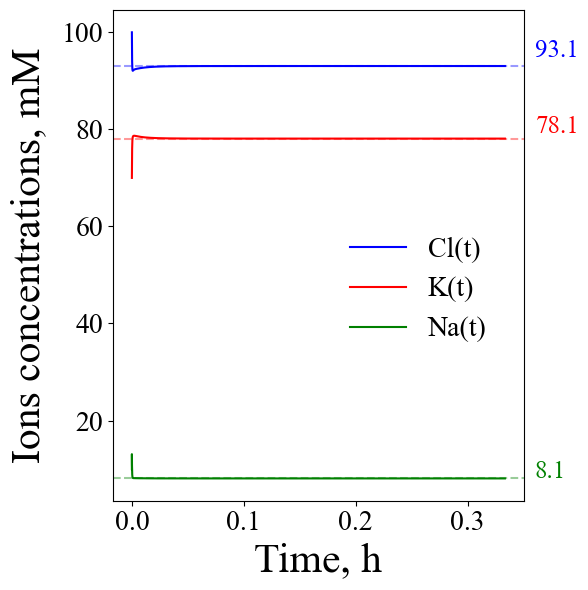

In [27]:
plot_solution_concentrations(tspan, solution, solution_stat=solution_stat, V_arr=V_arr, V_arr_stat=V_arr_stat,
                              legend_loc=[0.55, 0.3], save=False, save_name='normal')


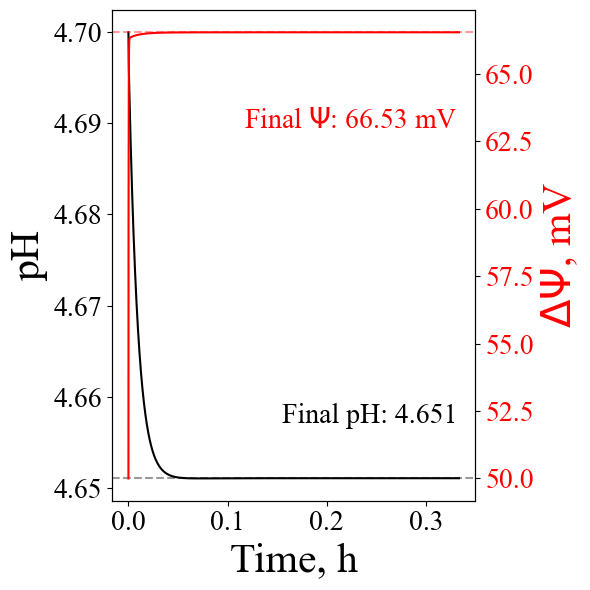

In [28]:
plot_solution_pH_psi(tspan, solution, solution_stat, psi_arr, psi_arr_stat[-1], psi_text=0.8, pH_text=0.2, save_name='normal', save = False)

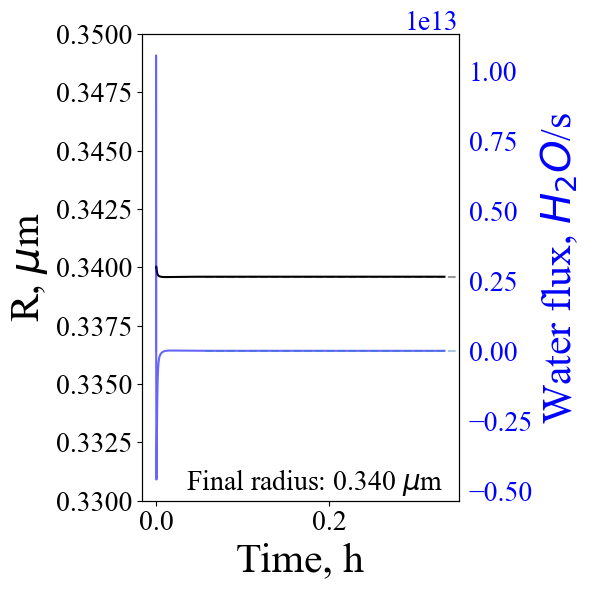

In [29]:
plot_solution_R(tspan, solution, solution_stat, V_arr, V_arr_stat, J_w_arr, J_w_arr_stat, R_text=0.07, swelling=0,
                set_Rlim = True, Rlim = [0.33, 0.35], save=True, save_name='normal')

# Short vATPase shutdown

In [30]:
X0 = [init_Aeff, init_NH, init_pH, init_NK, init_NNa, init_NCl, init_NCa_T, init_NCa_F, init_R]

In [31]:
stress_name = 'Fast_vATPase'

In [32]:
tspan = np.arange(0, 2500, 1e-2)
solution = odeint(derivatives, X0, tspan, args=('Fast_vastpase_stress', 1))
tspan_stat = np.arange(0, 40000, 1e-2)
solution_stat = odeint(derivatives, X0, tspan_stat, args=('Fast_vastpase_stress', 1))

In [33]:
V_arr = V_arr_def(solution)
psi_arr = Psi_arr_def(solution, V_arr)
J_w_arr = J_w_arr_def(solution, V_arr)

V_arr_stat = V_arr_def(solution_stat)
psi_arr_stat = Psi_arr_def(solution_stat, V_arr_stat)
J_w_arr_stat = J_w_arr_def(solution_stat, V_arr_stat)

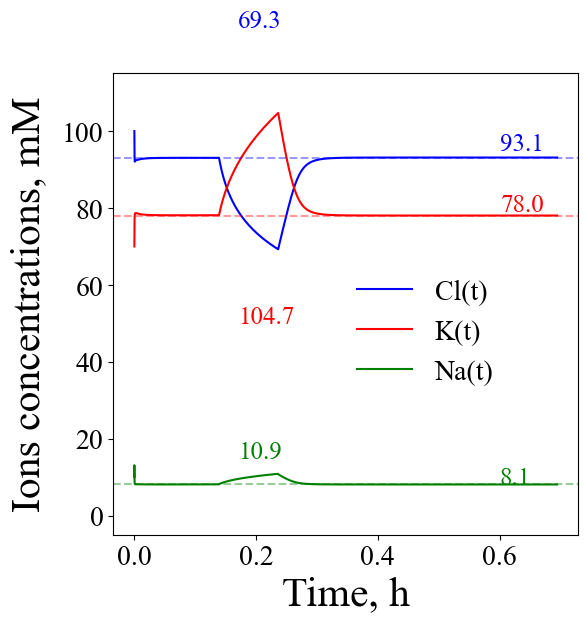

In [34]:
plot_solution_concentrations_stress(tspan, solution, solution_stat=solution_stat, V_arr=V_arr, V_arr_stat=V_arr_stat,
                             legend_loc=[0.5, 0.3], save=True, save_name='Fast_vATPase', x_text=0.6, stress_time=[50000, 85000], x_stress_text=0.17, hand_stress=1, 
                             hand_stress_text=[127, 50, 15])


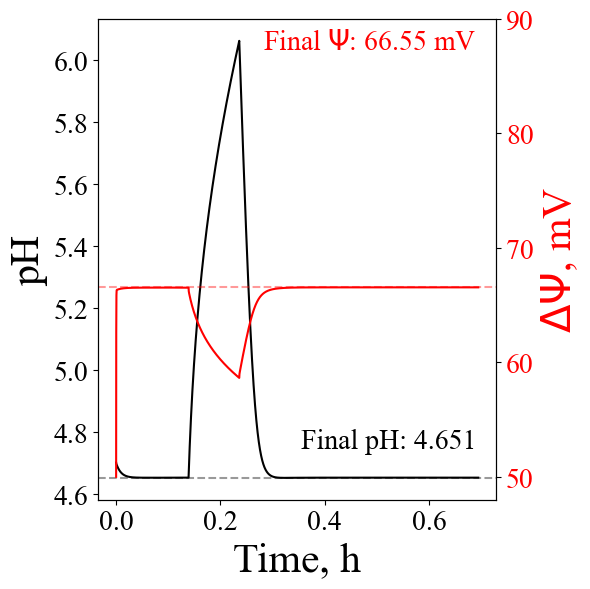

In [35]:
plot_solution_pH_psi(tspan, solution, solution_stat, psi_arr, psi_arr_stat[-1], psi_text=0.98, pH_text=0.15,
                     set_psi_lim=True, psi_lim=[48, 90],
                     set_pHlim= 0, pHlim=[4.5, 5.5], save=True, save_name='Fast_vATPase')

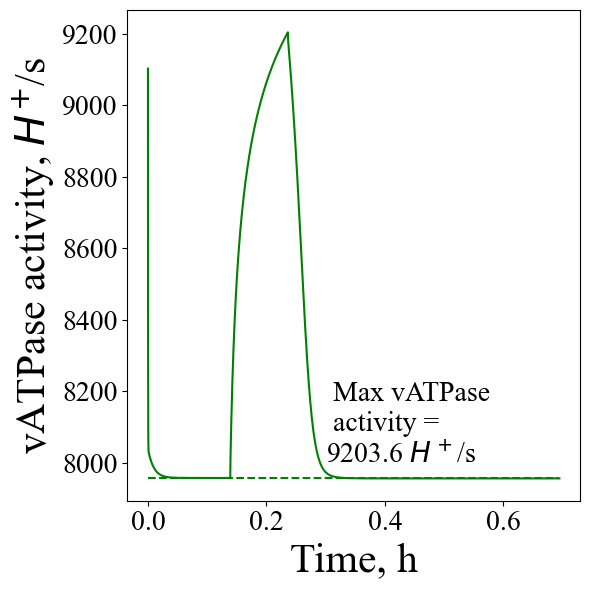

In [36]:
plot_vATPase_work(tspan, solution, solution_stat, 'Short_vATPase', psi_arr, psi_arr_stat, text = 'max', text_loc = [0.3,8000])

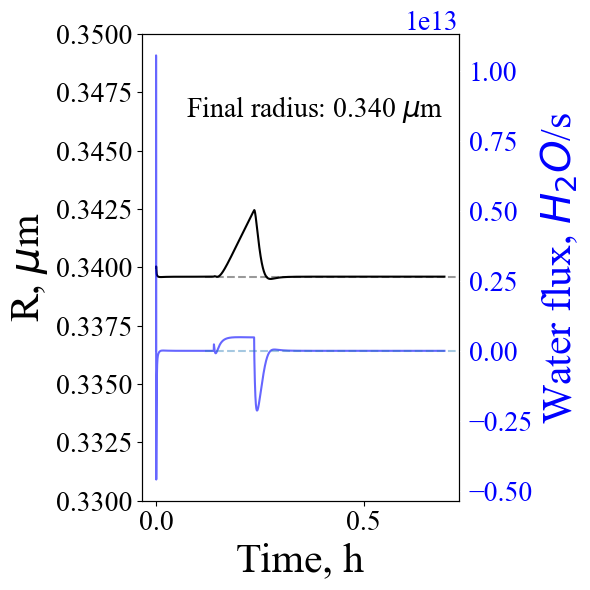

In [37]:
plot_solution_R(tspan, solution, solution_stat, V_arr, V_arr_stat, J_w_arr, J_w_arr_stat, R_text=0.87, swelling=0,
                set_Rlim = True, Rlim = [0.33, 0.35], save=True, save_name=stress_name)

## Fast swelling

In [38]:
stress_name = 'Fast_swelling'

In [39]:
tspan = np.arange(0, 1200, 1e-2)
solution = odeint(derivatives, X0, tspan, args=('Fast_swelling',))
tspan_stat = np.arange(0, 40000, 1e-2)
solution_stat = odeint(derivatives, X0, tspan_stat, args=('Fast_swelling',))

In [40]:
V_arr = V_arr_def(solution)
psi_arr = Psi_arr_def(solution, V_arr)
J_w_arr = J_w_arr_def(solution, V_arr)

V_arr_stat = V_arr_def(solution_stat)
psi_arr_stat = Psi_arr_def(solution_stat, V_arr_stat)
J_w_arr_stat = J_w_arr_def(solution_stat, V_arr_stat)

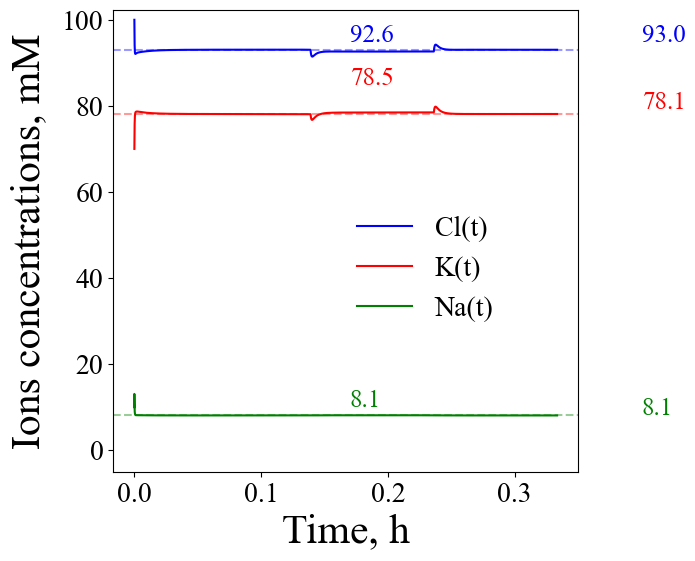

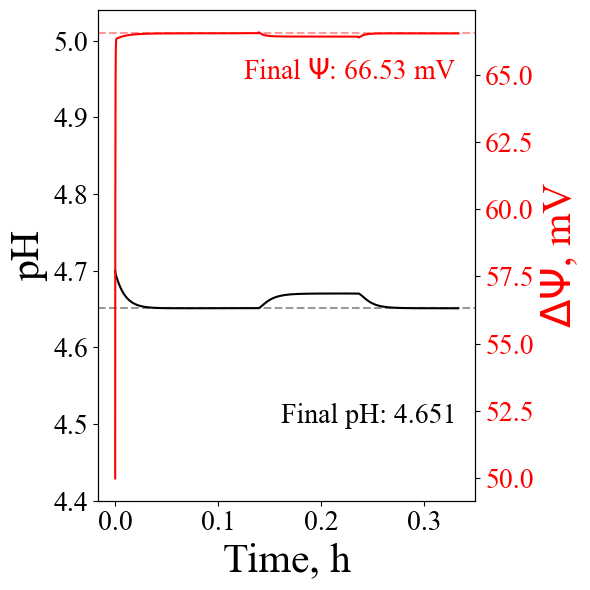

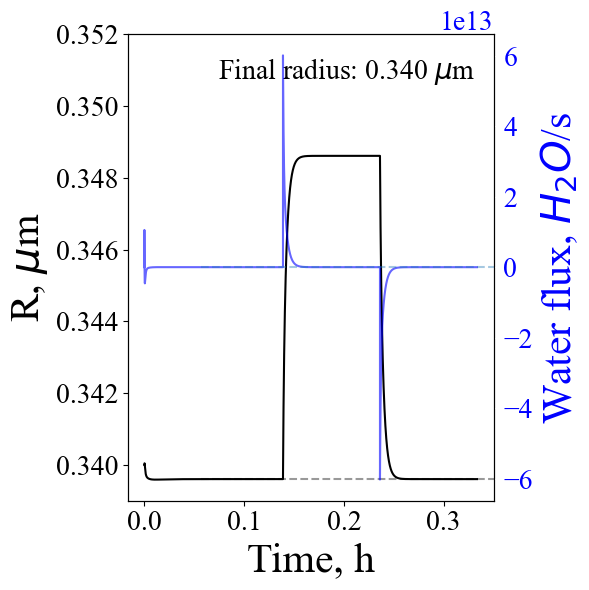

In [41]:
# plot_solution_concentrations(tspan, solution, solution_stat=solution_stat, V_arr=V_arr, V_arr_stat=V_arr_stat,
#                              legend_loc=[0.55, 0.3], save = True, save_name=stress_name)

plot_solution_concentrations_stress(tspan, solution, solution_stat=solution_stat, V_arr=V_arr, V_arr_stat=V_arr_stat,
                             legend_loc=[0.5, 0.3], save=True, save_name=stress_name, x_text=0.4, stress_time=[50000, 85000], x_stress_text=0.17, hand_stress=1, 
                             hand_stress_text=[95, 85, 10])



plot_solution_pH_psi(tspan, solution, solution_stat, psi_arr, psi_arr_stat[-1], psi_text=0.9, pH_text=0.2,
                     set_pHlim=True, pHlim=[4.4, 5.04], save=True, save_name=stress_name)
plot_solution_R(tspan, solution, solution_stat, V_arr, V_arr_stat, J_w_arr, J_w_arr_stat, R_text=0.95, swelling=1,
                set_Rlim = True, Rlim = [0.339, 0.352], save=True, save_name=stress_name)

# Permeabilization

## Increase in ions permeabilities 10-fold

In [42]:
stress_name = 'Permeabilization10'

In [43]:
tspan = np.arange(0, 3000, 1e-2)
solution = odeint(derivatives, X0, tspan, args=('Permeabilization10',), hmax=1e-2)
tspan_stat = np.arange(0, 40000, 1e-2)


In [44]:
V_arr = V_arr_def(solution)
psi_arr = Psi_arr_def(solution, V_arr)
J_w_arr = J_w_arr_def(solution, V_arr)

# V_arr_stat = V_arr_def(solution_stat)
# psi_arr_stat = Psi_arr_def(solution_stat, V_arr_stat)
# J_w_arr_stat = J_w_arr_def(solution_stat, V_arr_stat)

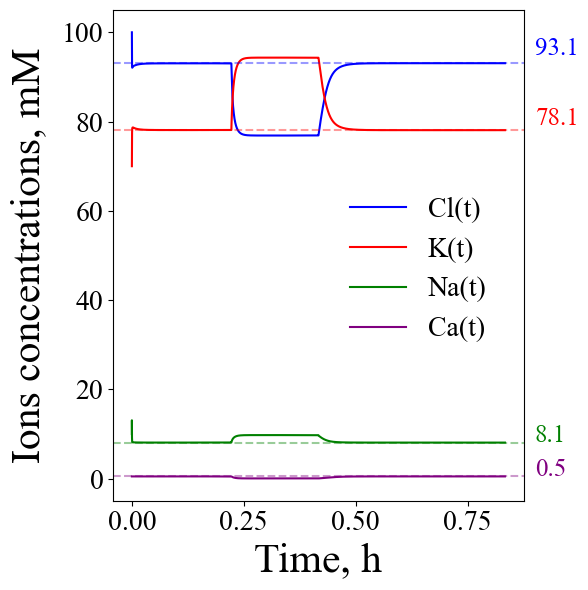

In [45]:
plot_solution_concentrations(tspan, solution, solution_stat=solution, V_arr=V_arr, V_arr_stat=V_arr,
                             x_text=0.9, legend_loc=[0.55, 0.3], save=True, save_name=stress_name, show_Ca=True)


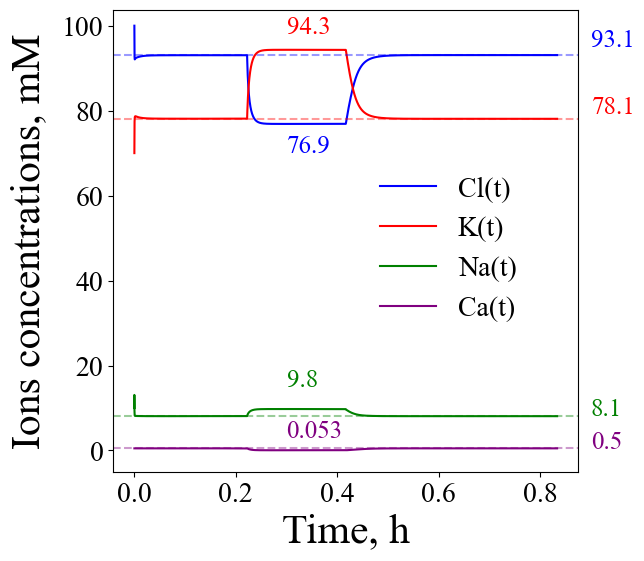

In [46]:
plot_solution_concentrations_stress(tspan, solution, solution_stat=solution, V_arr=V_arr, V_arr_stat=V_arr,
                             x_text=0.9, legend_loc=[0.55, 0.3], save=True, save_name=stress_name, show_Ca=True, 
                             x_stress_text=0.3, hand_stress=1, hand_stress_text=[70, 98, 15])


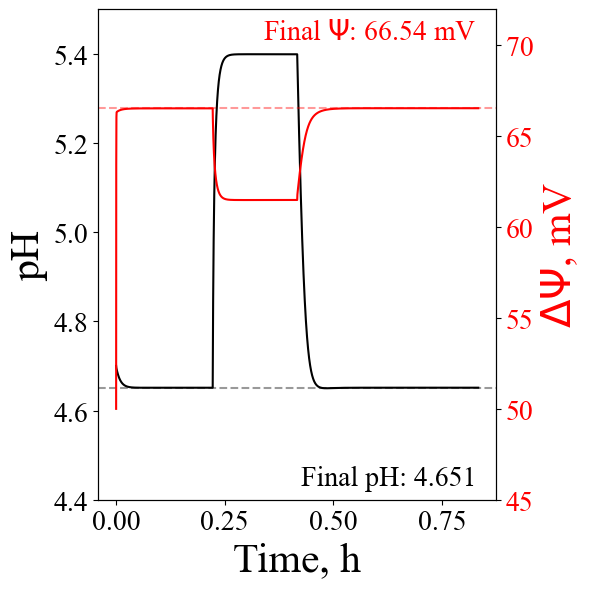

In [47]:
plot_solution_pH_psi(tspan, solution, solution, psi_arr, psi_arr[-1], 
                     psi_text=0.98, pH_text=0.07, set_pHlim=True, pHlim=[4.4, 5.5],
                     set_psi_lim=True, psi_lim=[45, 72],
                     save = True, save_name=stress_name)

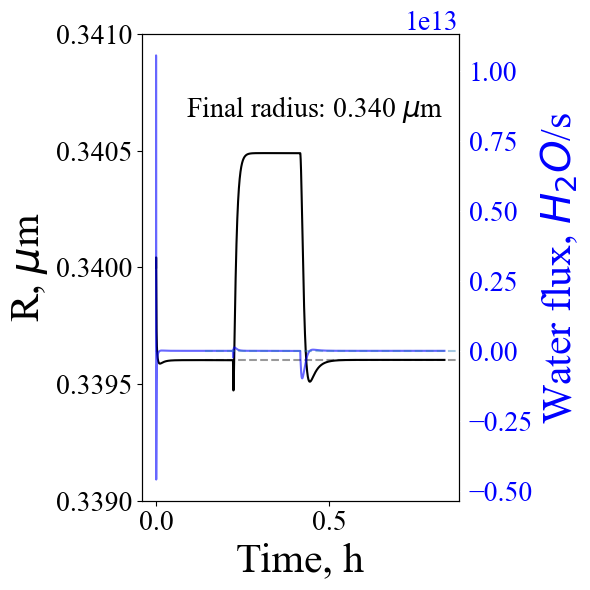

In [48]:
plot_solution_R(tspan, solution, solution_stat, V_arr, V_arr_stat, J_w_arr, J_w_arr_stat, R_text=0.87, swelling=0,
                set_Rlim = True, Rlim = [0.339, 0.341], save=True, save_name=stress_name)

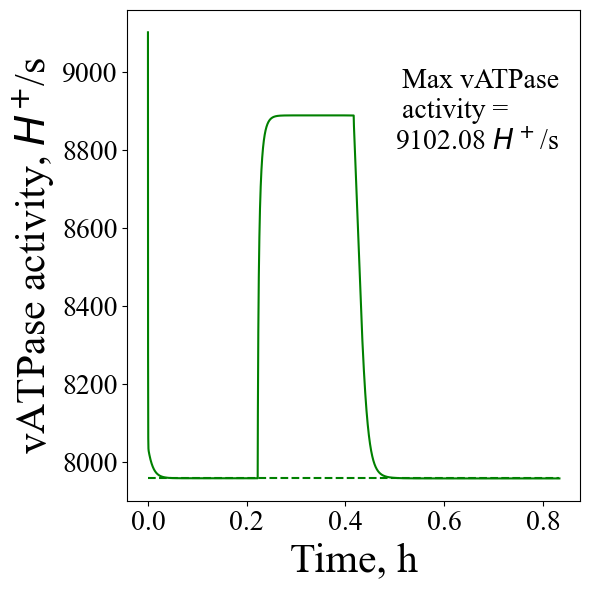

In [49]:
plot_vATPase_work(tspan, solution, solution, 'permeabilization10', psi_arr, psi_arr, text = 'max', text_loc = [0.5, 8800])

## Increase in ions permeabilities 100-fold

In [50]:
stress_name = 'Permeabilization100'

In [51]:
tspan = np.arange(0, 3000, 1e-2)
solution = odeint(derivatives, X0, tspan, args=('Permeabilization100',), hmax=1e-2)
tspan_stat = np.arange(0, 40000, 1e-2)
# solution_stat = odeint(derivatives, X0, tspan_stat, args=('Permeabilization',))

In [52]:
V_arr = V_arr_def(solution)
psi_arr = Psi_arr_def(solution, V_arr)
J_w_arr = J_w_arr_def(solution, V_arr)

# V_arr_stat = V_arr_def(solution_stat)
# psi_arr_stat = Psi_arr_def(solution_stat, V_arr_stat)
# J_w_arr_stat = J_w_arr_def(solution_stat, V_arr_stat)

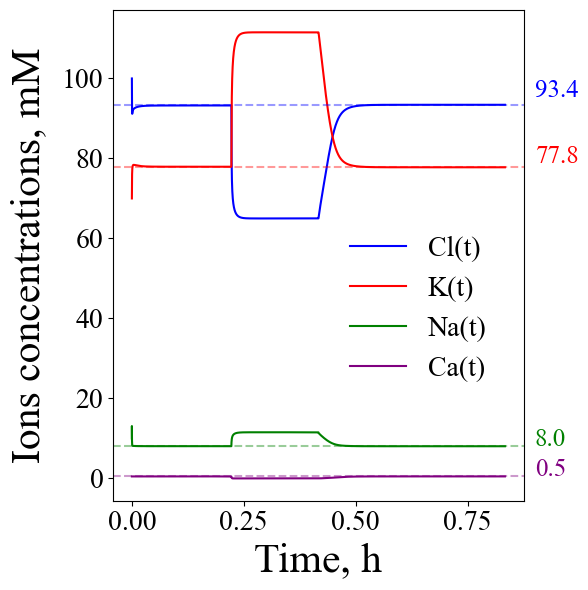

In [53]:
plot_solution_concentrations(tspan, solution, solution_stat=solution, V_arr=V_arr, V_arr_stat=V_arr,
                             x_text=0.9, legend_loc=[0.55, 0.22], save=True, save_name=stress_name, show_Ca=True)


111.54129224096128


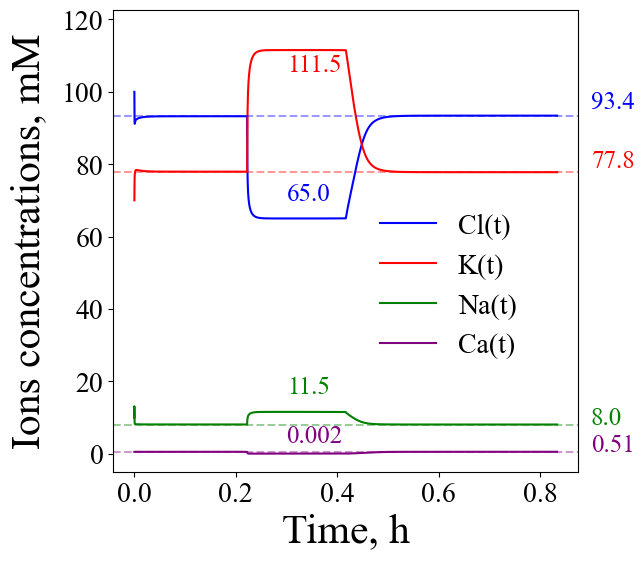

In [54]:
plot_solution_concentrations_stress(tspan, solution, solution_stat=solution, V_arr=V_arr, V_arr_stat=V_arr, stress_time=[80000, 150000],
                             x_text=0.9, x_stress_text=0.3, legend_loc=[0.55, 0.22], save=True, save_name=stress_name, show_Ca=True)


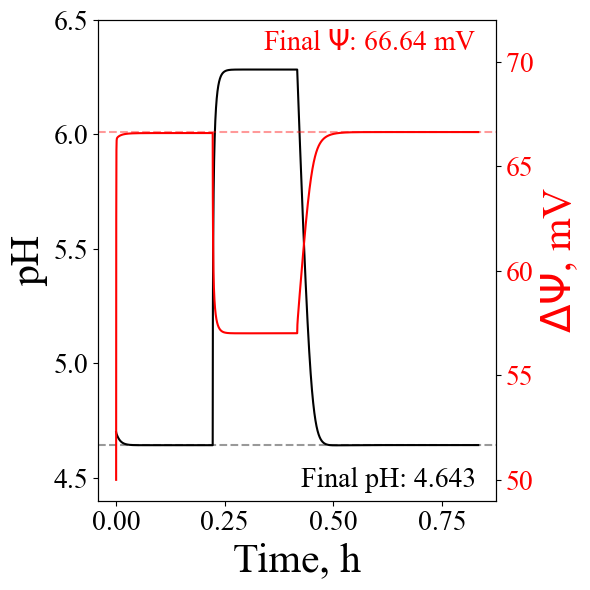

In [55]:
plot_solution_pH_psi(tspan, solution, solution, psi_arr, psi_arr[-1], 
                     psi_text=0.98, pH_text=0.07, set_pHlim=True, pHlim=[4.4, 6.5],
                     set_psi_lim=True, psi_lim=[49, 72],
                     save = True, save_name=stress_name)

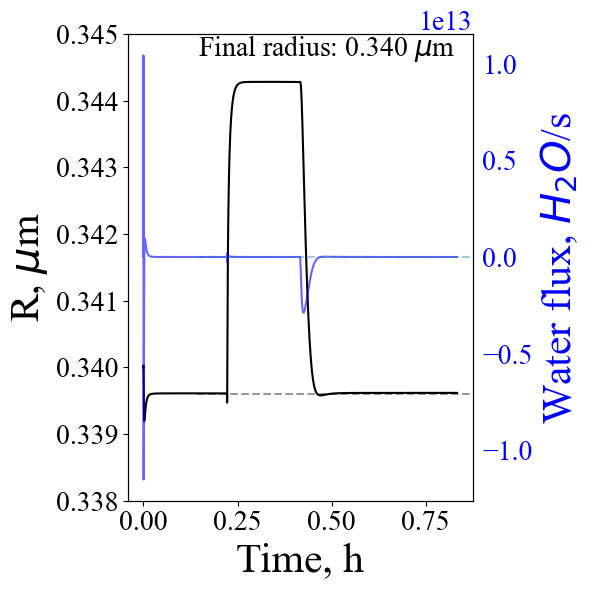

In [56]:
plot_solution_R(tspan, solution, solution_stat, V_arr, V_arr_stat, J_w_arr, J_w_arr_stat, R_text=1.0, swelling=0,
                set_Rlim = True, Rlim = [0.338, 0.345], save=True, save_name=stress_name)

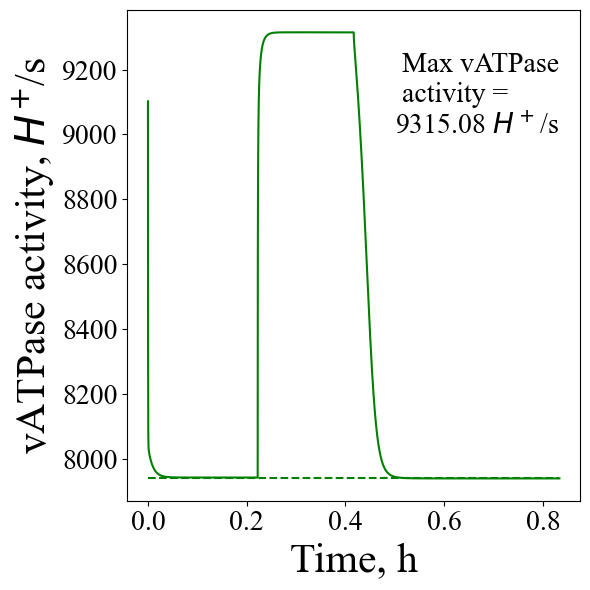

In [57]:
plot_vATPase_work(tspan, solution, solution, 'permeabilization100', psi_arr, psi_arr, text = 'max', text_loc = [.5, 9000])

# Ca-signaling

## vATPase partial inhibition

In [58]:
tspan = np.arange(0, 8000, 1e-2)
solution = odeint(derivatives, X0, tspan, args=('Ca_v',))
tspan_stat = np.arange(0, 40000, 1e-2)
solution_stat = odeint(derivatives, X0, tspan_stat, args=('Ca_v',))

In [59]:
V_arr = V_arr_def(solution)
psi_arr = Psi_arr_def(solution, V_arr)
J_w_arr = J_w_arr_def(solution, V_arr)

V_arr_stat = V_arr_def(solution_stat)
psi_arr_stat = Psi_arr_def(solution_stat, V_arr_stat)
J_w_arr_stat = J_w_arr_def(solution_stat, V_arr_stat)

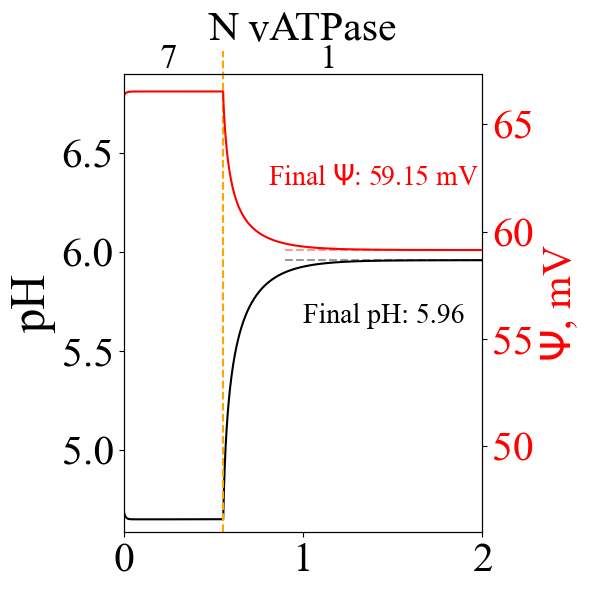

In [60]:

def plot_solution_pH_psi_Ca_v(t, solution, solution_stat, psi_arr, psi_stat,
                              save = False, save_folder = 'figs_TMEM165'):
    fig, ax1 = plt.subplots(figsize=(6, 6), dpi=100)

    t = t/3600

    # Plot R(t)
    ax1.plot(t, solution[:, 2], 'black', label='pH$(t)$')
    ax1.set_ylabel(r'pH', fontsize=35, color='black')
    ax1.tick_params(axis='y', colors='black')
    ax1.axhline(solution_stat[:, 2][-1], 0.45, 1, color = 'black', clip_on=False, linestyle='dashed', alpha = 0.4)
    ax1.text(0.95, 0.5, 'Final pH: {:.2f}'.format(solution_stat[:, 2][-1]), transform=ax1.transAxes, ha='right', va='top', fontsize=20, color='black')
    ax1.set_ylim(ymax = 6.9)
    # Create a second y-axis for J_w_arr
    ax2 = ax1.twinx()

    # Plot J_w_arr
    psi_arr = (F/cap)*init_V*(solution[:, 1]/init_V/NA + solution[:, 3]/init_V/NA + solution[:, 4]/init_V/NA - solution[:, 5]/init_V/NA + 2*solution[:, 6]/init_V/NA - B)

    ax2.plot(t, psi_arr, 'r', label=r'$\Psi$(t)', alpha=1)  # Set transparency with alpha
    ax2.set_ylabel(r'$\Psi$, mV', fontsize=30, color='r')
    ax2.tick_params(axis='y', colors='black', labelcolor='red')
    ax2.axhline(psi_stat, 0.45, 1, color = 'r', clip_on=False, linestyle='dashed', alpha = 0.4)
    ax2.text(0.99, 0.8, 'Final $\Psi$: {:.2f} mV'.format(psi_stat), transform=ax2.transAxes, ha='right', va='top', fontsize=20, color='r')

    ax2.set_ylim(ymin = 46)
    

    # Set the x-axis label and tick color
    plt.xlabel('Time, h', fontsize=35)
    ax1.tick_params(axis='x', colors='k')  # Set x-tick color to black
    ax1.tick_params(axis='both', labelsize=30)
    ax2.tick_params(axis='both', labelsize=30)

    ax1.axvline(2000/3600, 0, 1.05, color = 'orange', clip_on=False, linestyle='dashed', alpha = 1)
    ax1.text(0.2, 6.93, s='7', fontsize=25, color='black')
    ax1.text(1, 6.93, s='  1', fontsize=25, color='black')
    # ax1.text(0.6, 7.5, s='N vATPase', fontsize=25, color='black')
    #add space between plot and title
    plt.title('N vATPase', fontsize=30, color='black', pad = 25)
    plt.xlim(0,2)

    plt.tight_layout()

    if save:
        plt.savefig(f'{save_folder}/pH_psi_Ca_v.png', dpi = 300)
    plt.show()




plot_solution_pH_psi_Ca_v(tspan, solution, solution_stat, psi_arr, psi_arr_stat[-1], save=True)


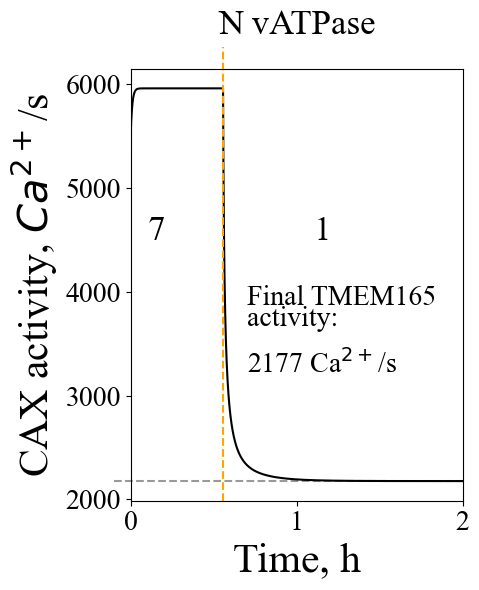

In [61]:
def plot_TMEM165_work_v(t_s, solution, solution_stat, psi_arr, psi_arr_stat, V_arr, V_arr_stat, save = 'False',
                        save_folder = 'figs_TMEM165'):
    fig, ax = plt.subplots(figsize=(5, 6), dpi=100)
    t = t_s/3600
    pH_arr = solution[:, 2]
    Ca_F = solution[:, 6]/V_arr/NA 
    Ca_F_C0 = Ca_C*exp(-2*psi_out/RTF) 
    Ca_F_L0 = Ca_F*exp(-2*psi_in/RTF) 
    init_S = 4*3.1416*init_R**2*1e-8 
    pH_C0   = (pH_C+psi_out/(RTF*2.3))
    pH_L0   = (pH_arr+psi_in/(RTF*2.3))
    delta_pH    = pH_C0-pH_L0
    gg      =  psi_arr / (1 - exp (- psi_arr / RTF)) / RTF
    J_Ca_TMEM165 = init_S*(10**(-pH_C0)*exp(-psi_arr/RTF)-10**(-pH_L0))*gg*NA/1000-2*((TMEM165_H - 2*TMEM165_Ca)*psi_arr + RTF*(TMEM165_Ca/2*np.log(Ca_F_L0/Ca_F_C0)))*1e6
    N_TMEM165 = 0.0000035*2
    J_TMEM165 = -N_TMEM165*J_Ca_TMEM165



    pH_arr_stat = solution_stat[:, 2]
    Ca_F_stat = solution_stat[:, 6]/V_arr_stat/NA
    Ca_F_C0_stat = Ca_C*exp(-2*psi_out/RTF)
    Ca_F_L0_stat = Ca_F_stat*exp(-2*psi_in/RTF)

    pH_C0_stat   = (pH_C+psi_out/(RTF*2.3))
    pH_L0_stat   = (pH_arr_stat+psi_in/(RTF*2.3))
    delta_pH_stat    = pH_C0_stat-pH_L0_stat

    gg_stat = psi_arr_stat / (1 - exp (- psi_arr_stat / RTF)) / RTF

    J_Ca_TMEM165_stat = init_S*(10**(-pH_C0_stat)*exp(-psi_arr_stat/RTF)-10**(-pH_L0_stat))*gg_stat*NA/1000-2*((TMEM165_H - 2*TMEM165_Ca)*psi_arr_stat + RTF*(TMEM165_Ca/2*np.log(Ca_F_L0_stat/Ca_F_C0_stat)))*1e6
    J_TMEM165_stat = -N_TMEM165*J_Ca_TMEM165_stat
    


    



    

    ax.plot(t, J_TMEM165, 'black', label='J_v$(t)$')
    ax.axhline(J_TMEM165_stat[-1], -0.05, 1, color = 'black', clip_on=False, linestyle='dashed', alpha = 0.4)
    plt.ylabel(r'CAX activity, $Ca^{2+}$/s', fontsize=30)
    plt.xlabel('Time, h', fontsize=30)
    ax.axvline(2000/3600, 0, 1.05, color = 'orange', clip_on=False, linestyle='dashed', alpha = 1)
    ax.text(0.1, 4500, s='7', fontsize=25, color='black')
    ax.text(1, 4500, s='  1', fontsize=25, color='black')
    ax.set_xlim(0, 2)
    
    plt.title('N vATPase', fontsize=25, color='black', pad = 25) 
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    


    ax.text(0.35, 0.5, 'Final TMEM165', transform=ax.transAxes, ha='left', va='top', fontsize=20, color='black')
    ax.text(0.35, 0.45, 'activity:', transform=ax.transAxes, ha='left', va='top', fontsize=20, color='black')

    ax.text(0.35, 0.35, f'{J_TMEM165_stat[-1]:.0f} Ca$^{{2+}}$/s', transform=ax.transAxes, ha='left', va='top', fontsize=20, color='black')  
    plt.tight_layout()
    if save:
        plt.savefig(f'{save_folder}/TMEM165_work_Ca_v.png', dpi=300)
    plt.show()


plot_TMEM165_work_v(tspan, solution, solution_stat, psi_arr, psi_arr_stat, V_arr, V_arr_stat, save = 'True')

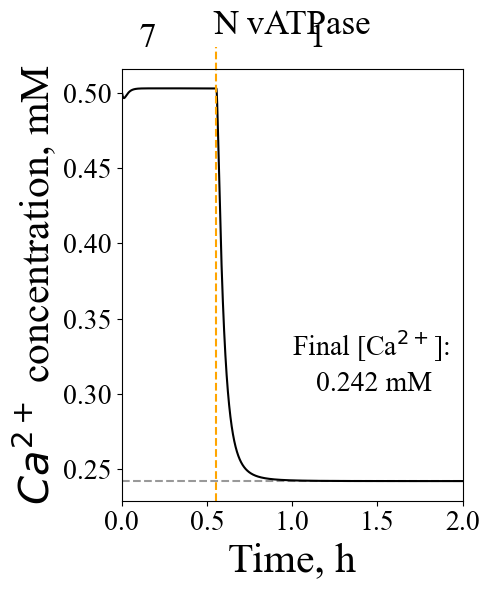

0.5028404272901912


In [62]:
def plot_solution_Ca_v(t_s, solution, solution_stat, V_arr, V_arr_stat, 
                       save= False, save_folder = 'figs_TMEM165'):
    fig, ax = plt.subplots(figsize=(5, 6), dpi=100)

    t = t_s/3600
    ca_conc = solution[:, 7] / V_arr / NA*1000
    ca_stat = solution_stat[:, 7][-1] / V_arr_stat[-1] / NA*1000
    # Plot the concentrations
    ax.plot(t, ca_conc, 'black')
    ax.axhline(ca_stat, 0, 1, color = 'black', clip_on=False, linestyle='dashed', alpha = 0.4)

    plt.ylabel(r'$Ca^{2+}$ concentration, mM', fontsize=30)
    plt.xlabel('Time, h', fontsize=30)
    ax.tick_params(axis='both', labelsize=20)
    # Add a vertical dashed line 
    ax.axvline(2000/3600, 0, 1.05, color = 'orange', clip_on=False, linestyle='dashed', alpha = 1)
    ax.text(0.1, .53, s='7', fontsize=25, color='black')
    ax.text(1, .53, s='  1', fontsize=25, color='black')
    plt.title('N vATPase', fontsize=25, color='black', pad = 25) 
    plt.tight_layout()
    ax.text(0.5, 0.4, 'Final [Ca$^{2+}$]:', transform=ax.transAxes, ha='left', va='top', fontsize=20, color='black')
    ax.text(0.57, 0.3, f'{ca_stat:.3f} mM', transform=ax.transAxes, ha='left', va='top', fontsize=20, color='black')  
    ax.tick_params(axis='both', labelsize=20)
    ax.set_xlim(0, 2)
    plt.tight_layout()
    if save:
        plt.savefig(f'{save_folder}/Ca_Ca_v.png')
    plt.show()
    print(ca_conc[80000])


plot_solution_Ca_v(tspan, solution, solution_stat, V_arr, V_arr_stat, save=True)


## Pure de-acidification = proton efflux

In [63]:
tspan = np.arange(0, 8000, 1e-2)
solution = odeint(derivatives, X0, tspan, args=('Ca_al',))
tspan_stat = np.arange(0, 40000, 1e-2)
solution_stat = odeint(derivatives, X0, tspan_stat, args=('Ca_al',))

In [64]:
V_arr = V_arr_def(solution)
psi_arr = Psi_arr_def(solution, V_arr)
J_w_arr = J_w_arr_def(solution, V_arr)

V_arr_stat = V_arr_def(solution_stat)
psi_arr_stat = Psi_arr_def(solution_stat, V_arr_stat)
J_w_arr_stat = J_w_arr_def(solution_stat, V_arr_stat)

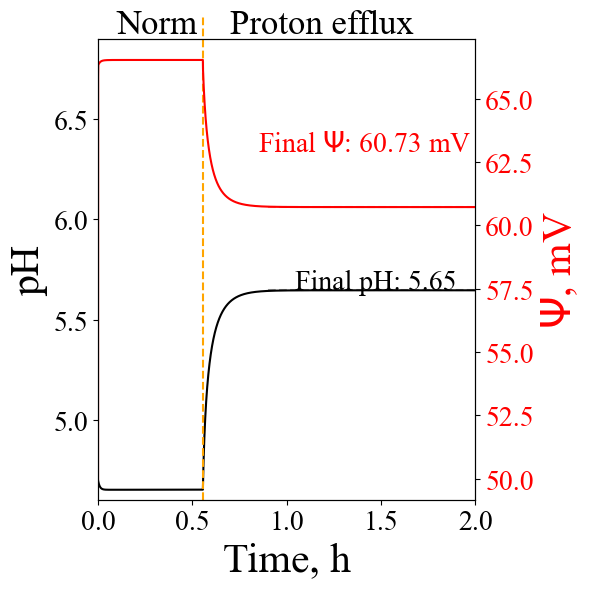

In [65]:
def plot_solution_pH_psi_Ca_a(t, solution, solution_stat, psi_arr, psi_stat, save = 'False', save_folder = 'figs_TMEM165'):
    fig, ax1 = plt.subplots(figsize=(6, 6), dpi=100)

    t = t/3600

    # Plot R(t)
    ax1.plot(t, solution[:, 2], 'black', label='pH$(t)$')
    ax1.set_ylabel(r'pH', fontsize=30, color='black')
    ax1.tick_params(axis='y', colors='black')
    ax1.axhline(solution_stat[:, 2][-1], 0.45, 1, color = 'black', clip_on=False, linestyle='dashed', alpha = 0.4)
    ax1.text(0.95, 0.5, 'Final pH: {:.2f}'.format(solution_stat[:, 2][-1]), transform=ax1.transAxes, ha='right', va='top', fontsize=20, color='black')
    ax1.set_ylim(ymax = 6.9)
    # Create a second y-axis for J_w_arr
    ax2 = ax1.twinx()

    # Plot J_w_arr
    psi_arr = (F/cap)*init_V*(solution[:, 1]/init_V/NA + solution[:, 3]/init_V/NA + solution[:, 4]/init_V/NA - solution[:, 5]/init_V/NA + 2*solution[:, 6]/init_V/NA - B)

    ax2.plot(t, psi_arr, 'r', label=r'$\Psi$(t)', alpha=1)  # Set transparency with alpha
    ax2.set_ylabel(r'$\Psi$, mV', fontsize=30, color='r')
    ax2.tick_params(axis='y', colors='black', labelcolor='red')
    ax2.axhline(psi_stat, 0.45, 1, color = 'r', clip_on=False, linestyle='dashed', alpha = 0.4)
    ax2.text(0.99, 0.8, 'Final $\Psi$: {:.2f} mV'.format(psi_stat), transform=ax2.transAxes, ha='right', va='top', fontsize=20, color='r')

    # ax2.set_ylim(ymin = 46)
    

    # Set the x-axis label and tick color
    ax1.set_xlabel('Time, h', fontsize=30)
    ax1.tick_params(axis='x', colors='k')  # Set x-tick color to black


    ax1.axvline(2000/3600, 0, 1.05, color = 'orange', clip_on=False, linestyle='dashed', alpha = 1)
    ax1.text(0.7, 6.93, s='Proton efflux', fontsize=25, color='black')
    ax1.text(0.1, 6.93, s='Norm', fontsize=25, color='black')
    # ax1.text(0.6, 7.5, s='N vATPase', fontsize=25, color='black')
    #add space between plot and title
    ax1.tick_params(axis='both', labelsize=20)
    ax2.tick_params(axis='both', labelsize=20)
    plt.xlim(0, 2)
    plt.tight_layout()
    if save:
        plt.savefig(f'{save_folder}/pH_psi_Ca_a.png', dpi=300)

    plt.show()
plot_solution_pH_psi_Ca_a(tspan, solution, solution_stat, psi_arr, psi_arr_stat[-1], save=True)


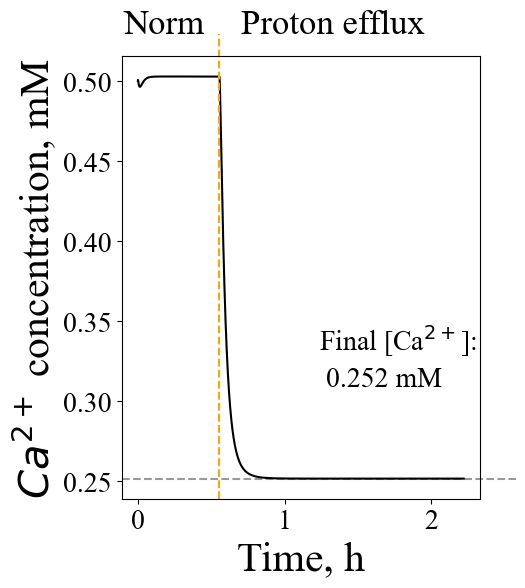

In [66]:
def plot_solution_Ca_a(t_s, solution, solution_stat, V_arr, V_arr_stat, save=False, save_folder = 'figs_TMEM165'):
    fig, ax = plt.subplots(figsize=(5, 6), dpi=100)

    t = t_s/3600
    ca_conc = solution[:, 7] / V_arr / NA*1000
    ca_stat = solution_stat[:, 7][-1] / V_arr_stat[-1] / NA*1000
    # Plot the concentrations
    ax.plot(t, ca_conc, 'black')
    ax.axhline(ca_stat, 0, 1.1, color = 'black', clip_on=False, linestyle='dashed', alpha = 0.4)

    plt.ylabel(r'$Ca^{2+}$ concentration, mM', fontsize=30)
    plt.xlabel('Time, h', fontsize=30)
    ax.tick_params(axis='both', labelsize=20)
    # Add a vertical dashed line 
    ax.axvline(2000/3600, 0, 1.05, color = 'orange', clip_on=False, linestyle='dashed', alpha = 1)
    ax.text(-0.1, 0.53, s='Norm', fontsize=25, color='black')
    ax.text(0.7, 0.53, s='Proton efflux', fontsize=25, color='black')
    ax.text(0.55, 0.4, 'Final [Ca$^{2+}$]:', transform=ax.transAxes, ha='left', va='top', fontsize=20, color='black')
    ax.text(0.57, 0.3, f'{ca_stat:.3f} mM', transform=ax.transAxes, ha='left', va='top', fontsize=20, color='black')  
    ax.tick_params(axis='both', labelsize=20)
    # plt.ylim(-0.025)
    plt.tight_layout()

    if save:
        plt.savefig(f'{save_folder}/Ca_Ca_a.png', dpi=300, bbox_inches='tight')

    
    plt.show()


plot_solution_Ca_a(tspan, solution, solution_stat, V_arr, V_arr_stat, save=True)

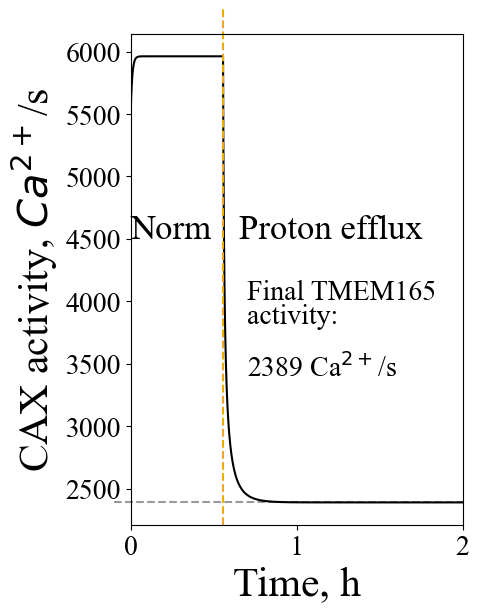

In [67]:

def plot_TMEM165_work_a(t_s, solution, solution_stat, psi_arr, psi_arr_stat, V_arr, V_arr_stat, save = 'False', 
                        save_folder = 'figs_TMEM165'):
    fig, ax = plt.subplots(figsize=(5, 6), dpi=100)
    t = t_s/3600
    pH_arr = solution[:, 2]
    Ca_F = solution[:, 6]/V_arr/NA 
    Ca_F_C0 = Ca_C*exp(-2*psi_out/RTF) 
    Ca_F_L0 = Ca_F*exp(-2*psi_in/RTF) 
    init_S = 4*3.1416*init_R**2*1e-8 
    pH_C0   = (pH_C+psi_out/(RTF*2.3))
    pH_L0   = (pH_arr+psi_in/(RTF*2.3))
   
    gg      =  psi_arr / (1 - exp (- psi_arr / RTF)) / RTF
    J_Ca_TMEM165 = init_S*(10**(-pH_C0)*exp(-psi_arr/RTF)-10**(-pH_L0))*gg*NA/1000-2*((TMEM165_H - 2*TMEM165_Ca)*psi_arr + RTF*(TMEM165_Ca/2*np.log(Ca_F_L0/Ca_F_C0)))*1e6
    N_TMEM165 = 0.0000035*2
    J_TMEM165 = -N_TMEM165*J_Ca_TMEM165



    pH_arr_stat = solution_stat[:, 2]
    Ca_F_stat = solution_stat[:, 6]/V_arr_stat/NA
    Ca_F_C0_stat = Ca_C*exp(-2*psi_out/RTF)
    Ca_F_L0_stat = Ca_F_stat*exp(-2*psi_in/RTF)

    pH_C0_stat   = (pH_C+psi_out/(RTF*2.3))
    pH_L0_stat   = (pH_arr_stat+psi_in/(RTF*2.3))


    gg_stat = psi_arr_stat / (1 - exp (- psi_arr_stat / RTF)) / RTF

    J_Ca_TMEM165_stat = init_S*(10**(-pH_C0_stat)*exp(-psi_arr_stat/RTF)-10**(-pH_L0_stat))*gg_stat*NA/1000-2*((TMEM165_H - 2*TMEM165_Ca)*psi_arr_stat + RTF*(TMEM165_Ca/2*np.log(Ca_F_L0_stat/Ca_F_C0_stat)))*1e6
    J_TMEM165_stat = -N_TMEM165*J_Ca_TMEM165_stat
    


    



    

    ax.plot(t, J_TMEM165, 'black', label='J_v$(t)$')
    ax.axhline(J_TMEM165_stat[-1], -0.05, 1, color = 'black', clip_on=False, linestyle='dashed', alpha = 0.4)
    plt.ylabel(r'CAX activity, $Ca^{2+}$/s', fontsize=30)
    plt.xlabel('Time, h', fontsize=30)
    ax.axvline(2000/3600, 0, 1.05, color = 'orange', clip_on=False, linestyle='dashed', alpha = 1)
    ax.text(0.65, 4500, s='Proton efflux', fontsize=25, color='black')
    ax.text(0, 4500, s='Norm', fontsize=25, color='black')
    ax.set_xlim(0, 2)
#     plt.title('N vATPase', fontsize=25, color='black', pad = 25) 
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    


    ax.text(0.35, 0.5, 'Final TMEM165', transform=ax.transAxes, ha='left', va='top', fontsize=20, color='black')
    ax.text(0.35, 0.45, 'activity:', transform=ax.transAxes, ha='left', va='top', fontsize=20, color='black')

    ax.text(0.35, 0.35, f'{J_TMEM165_stat[-1]:.0f} Ca$^{{2+}}$/s', transform=ax.transAxes, ha='left', va='top', fontsize=20, color='black')  
    plt.tight_layout()
    if save:
        plt.savefig(f'{save_folder}/TMEM165_work_Ca_.png', dpi=300)
    plt.show()


plot_TMEM165_work_a(tspan, solution, solution_stat, psi_arr, psi_arr_stat, V_arr, V_arr_stat, save = 'True')

# Accumulation of weak base, “proton sponge”-like cationic amphiphilic drug (CAD)

In [68]:
# init_Sp = 0.01
init_Sp = 0.00001

init_HSp = 0
# Sp_C = 0.001
ohsp = 0.73 

In [69]:
# @jit
def derivatives_sponge(X, t):
    '''
    compute derivatives of X wrt time
    '''
    Aeff, NH, pH, NK, NNa, NCl, NCa_T, NCa_F, R, NHSp = X


 

    N_VATP = 7
    p = 3.88e-12

    P_Ca = 1.49e-7      #[ion*cm/s]
    P_Cl = 1.2e-5       #[ion*cm/s]
    P_H = 6.2e-05      #[ion*cm/s]
    P_K = 7.1e-7 *1.6     #[ion*cm/s]
    P_Na = 9.6e-7*686/1000      #[ion*cm/s]
    Pw = 0.054e-2   #water permeability


    
     
    
    V = (4/3*3.1416*abs(R)**3*1e-12)/1000
    S = 4*3.1416*abs(R)**2*1e-8


    #Luminal Concentrations
    H = NH/V/NA
    K = NK/V/NA
    Na = NNa/V/NA
    Cl = NCl/V/NA
    Ca_F = NCa_F/V/NA
    Ca_T = NCa_T/V/NA
    r = Ca_F/Ca_T
    Sp = init_Sp
    HSp = NHSp/V/NA

    
    #membrane potential
#     psi = (F/cap)*init_V*(H + K + Na - Cl + 2*Ca_T - B)
    psi = (F/cap)*(V*(H + K + Na - Cl + 2*Ca_T + HSp) - B*init_V)

#      Modified Cytoplasmic Surface Concentrations
    pH_C0   = (pH_C+psi_out/(RTF*2.3))
    K_C0    = K_C*exp(-psi_out/RTF)
    Na_C0   = Na_C*exp(-psi_out/RTF) 
    Cl_C0   = Cl_C*exp(psi_out/RTF) 
    Ca_F_C0 = Ca_C*exp(-2*psi_out/RTF) 
    
#     Modified Luminal Surface Concentrations
    pH_L0   = (pH+psi_in/(RTF*2.3))
    K_L0    = K*exp(-psi_in/RTF)
    Na_L0   = Na*exp(-psi_in/RTF) 
    Cl_L0   = Cl*exp(psi_in/RTF) 
    Ca_F_L0 = Ca_F*exp(-2*psi_in/RTF) 

    delta_pH    = pH_C0-pH_L0;  

#     Treatment of singular terms for passive ion flux
    if (abs(psi) > 300):
        psi = np.sign(psi)*300
    if (abs(psi) > 0.01):
        gg      =  psi / (1 - exp (- psi / RTF)) / RTF
        gg_Ca   = 2*psi/(1-exp(-2*psi/RTF))/RTF

    else: 
        gg      =  1 / 1 - (psi / RTF)/2 + (psi / RTF)**2/6 - (psi / RTF)**3 / 24 + (psi / RTF) ** 4 / 120
        gg_Ca   = 1/(1 - (psi/RTF) + (2/3)*(psi/RTF)**2 - (1/3)*(psi/RTF)**3 +(2/15)*(psi/RTF)**4)
        

    # vAPTase
    J_VATPASE  = N_VATP * J_v(pH, psi)


        # ClC-7 Antiporter {H out, Cl in}
    CLC_mu      = (CLC_H + CLC_Cl)*psi + RTF*(CLC_H*2.3*delta_pH + CLC_Cl*np.log(Cl_C0/Cl_L0))
    
    #     Switching function   
    x = 0.5 + 0.5*np.tanh((CLC_mu + 250)/75); 
    # Activity
    A = 0.3*x + 1.5E-5*(1-x)*CLC_mu**2;
    
    if (A < Aeff):
        tau = tau_deact
    else:
        tau = tau_act
        
    J_CLC    = N_CLC*Aeff*CLC_mu 
    
    
    
#      Passive flux [ion/s]
    J_H = P_H*S*(10**(-pH_C0)*exp(-psi/RTF)-10**(-pH_L0))*gg*NA/1000
    J_K = P_K*S*(K_C0*exp(-psi/RTF)-K_L0)*gg*NA/1000
    J_Na = P_Na*S*(Na_C0*exp(-psi/RTF)-Na_L0)*gg*NA/1000

    J_Cl_unc = P_Cl*S*(Cl_C0-Cl_L0*exp(-psi/RTF))*gg*NA/1000
    J_Ca = P_Ca*S*(Ca_F_C0*exp(-2*psi/RTF)-Ca_F_L0)*gg_Ca*NA/1000
    


    
    #water flux
    J_w = Pw*S*(oh*10**(-pH) + ok*K + ona*Na + ocl*Cl + ohsp*HSp + Q/V - Oc)
    
#     TRPML1 channel
    y = 0.5 - 0.5*np.tanh(psi + 40)
    P_trpml1 = p*(y*abs(psi) + (1-y)*(abs (psi + 40)**3)/(pH_L0**q))
    J_Ca_trpml1 = P_trpml1*S*(Ca_F_C0*exp(-2*psi/RTF)-Ca_F_L0)*gg_Ca*NA/1000


    xh = 6.7e3*exp(-0.9*pH) - 15
    k = 11.3*pH**2 - 116.5*pH + 325.3
    P_TPC = 1/(1+exp((xh-psi)/k))
    J_TPC = N_TPC*P_TPC*S*(Na_C0*exp(-psi/RTF)-Na_L0)*gg*NA/1000
    #Sponge


    k_fus = 4000*1000
    k_fis = 0.00129

    w_fus = k_fus*np.power(10, -pH)*Sp

    w_fis = k_fis*HSp
    w = (w_fus-w_fis)*NA*V

    # w_fis = k_fis*HSp
    # w = (w_fus-w_fis)*NA*V
    # Sp_add_flux = 10e3


    #TMEM165
    J_Ca_TMEM165 = S*(10**(-pH_C0)*exp(-psi/RTF)-10**(-pH_L0))*gg*NA/1000-2*((TMEM165_H - 2*TMEM165_Ca)*psi + RTF*(TMEM165_Ca/2*np.log(Ca_F_L0/Ca_F_C0)))*1e6
    N_TMEM165 = 0.0000035*2

    if NCa_T + (J_Ca - TMEM165_Ca*J_Ca_TMEM165*N_TMEM165 + J_Ca_trpml1)<=0:
        J_Ca = 0
        J_Ca_trpml1 = 0
        J_Ca_TMEM165 = 0
        print('Ca concentration is too close to negative')
    
    dxdt = [(1/tau)*(A - Aeff),
           (J_H + (J_VATPASE) - (CLC_H*J_CLC) + TMEM165_H*(J_Ca_TMEM165*N_TMEM165) - w), 
           (-(J_H + (J_VATPASE) - (CLC_H*J_CLC) + TMEM165_H*(J_Ca_TMEM165*N_TMEM165) - w)/V/NA)/beta_pH,
           (J_K),
           (J_Na + J_TPC),
           (J_Cl_unc + (CLC_Cl*J_CLC)),
           (J_Ca - TMEM165_Ca*(J_Ca_TMEM165*N_TMEM165) + J_Ca_trpml1),
           (J_Ca - TMEM165_Ca*(J_Ca_TMEM165*N_TMEM165) + J_Ca_trpml1)*r, 
           J_w/(1000*55)/(4*np.pi*(R/1e5)**2)*1e5,
           w]
    
    

    return dxdt

In [70]:
def Psi_arr_sponge_def(solution, V_arr):
    psi_arr = (F/cap)*(V_arr*(solution[:, 1]/V_arr/NA + solution[:, 3]/V_arr/NA + solution[:, 4]/V_arr/NA - solution[:, 5]/V_arr/NA + 2*solution[:, 6]/V_arr/NA +  solution[:, 9] / V_arr / NA) - B*init_V)
    return psi_arr

In [71]:
init_NH = init_H*init_V*NA;      #[ions]
init_NK = init_K*init_V*NA;       
init_NNa = init_Na*init_V*NA;    
init_NCl = init_Cl*init_V*NA;     
init_NCa_T = init_Ca_T*init_V*NA; 
init_NCa_F = init_Ca_F*init_V*NA; 
init_NSp = init_Sp*init_V*NA; 

X0_sp = [init_Aeff, init_NH, init_pH, init_NK, init_NNa, init_NCl, init_NCa_T, init_NCa_F, init_R, init_HSp]

In [72]:
tspan = np.arange(0, 6000, 1e-2)
solution = odeint(derivatives_sponge, X0_sp, tspan)

tspan_stat = np.arange(0, 10000, 1e-2)
solution_stat = odeint(derivatives_sponge, X0_sp, tspan_stat)


In [73]:
def J_w_arr_sponge_def(solution, V_arr):
    init_Sp_arr = np.full(len(solution[:, 9]), init_Sp)
    J_w_arr = Pw*4*3.1416*abs(solution[:, 8])**2*1e-8*(oh*10**(-solution[:, 2]) + ok*solution[:, 3]/V_arr/NA + ona*solution[:, 4]/V_arr/NA + ocl*solution[:, 5]/V_arr/NA + ohsp*(solution[:, 9] / V_arr / NA)  + Q/V_arr - Oc)
    return J_w_arr*1000*NA

In [74]:
V_arr = V_arr_def(solution)
psi_arr = Psi_arr_sponge_def(solution, V_arr)
J_w_arr = J_w_arr_sponge_def(solution, V_arr)

V_arr_stat = V_arr_def(solution_stat)
psi_arr_stat = Psi_arr_sponge_def(solution_stat, V_arr_stat)
J_w_arr_stat = J_w_arr_sponge_def(solution_stat, V_arr_stat)

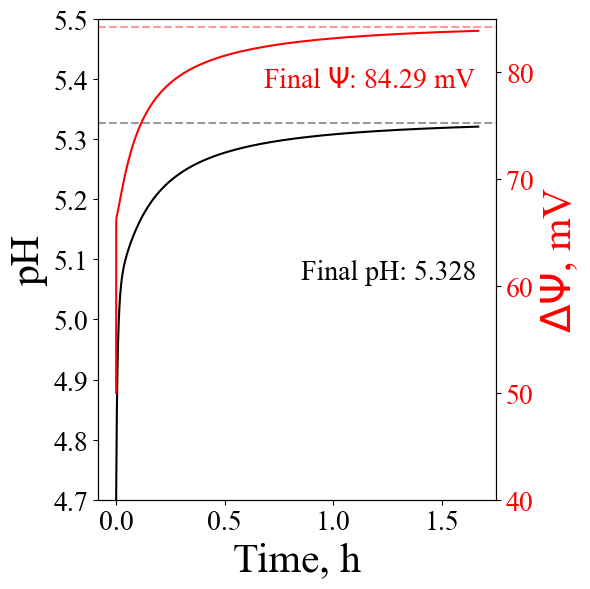

In [75]:
plot_solution_pH_psi(tspan, solution, solution_stat, psi_arr, psi_arr_stat[-1], psi_text=0.9, pH_text=0.5,
                     save = True, save_name='sponge', set_pHlim = True, pHlim = [4.7, 5.5], set_psi_lim = True, psi_lim = [40, 85])

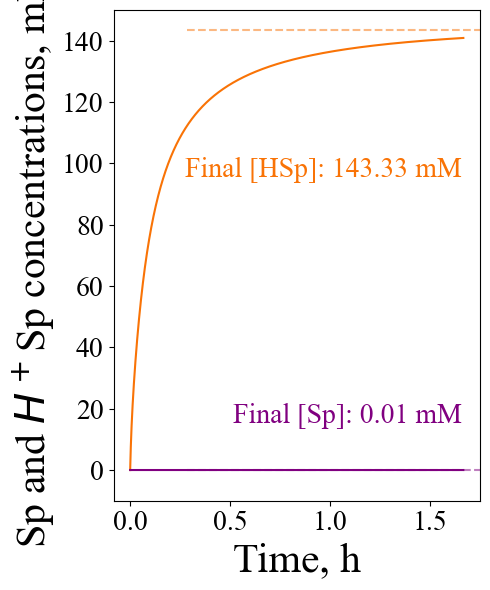

In [76]:
def plot_solution_sp(t, solution, solution_stat, V_arr, V_arr_stat, save = False, save_folder = 'figs_TMEM165'):
    t = t/3600
    fig, ax = plt.subplots(figsize=(5, 6), dpi=100)
    init_Sp_arr = np.full(len(solution[:, 9]), init_Sp)
    ax.plot(t, solution[:, 9] / V_arr / NA*1000, '#F97306', label='HSp')
    ax.plot(t, np.ones(len(t))*init_Sp*1000, '#800080', label='Sp')

    HSp_stat = solution_stat[:, 9][-1] / V_arr_stat[-1] / NA
    Sp_stat = init_Sp
    ax.axhline(y=Sp_stat*1000, xmin=0.2, xmax=1, color='#800080', linestyle='--', alpha=0.5)
    ax.axhline(y=HSp_stat*1000, xmin=0.2, xmax=1 ,color='#F97306', linestyle='--', alpha=0.5)


    ax.text(0.95, .7, 'Final [HSp]: {:.2f} mM'.format(HSp_stat*1000), transform=ax.transAxes, ha='right', va='top', 
            fontsize=20, color='#F97306')
    ax.text(0.95, 0.2, 'Final [Sp]: {:.2f} mM'.format(Sp_stat*1000), transform=ax.transAxes, ha='right', va='top', 
            fontsize=20, color='#800080')

    ax.set_xlabel(f'Time, h', fontsize=30)
    ax.set_ylabel(r'Sp and $H^+$Sp concentrations, mM', fontsize=30)
    ax.tick_params(axis='both', labelsize=15)
    # ax.legend(loc=(0.6, 0.2), fontsize=20, frameon=False)
    ax.tick_params(axis='both', labelsize=20)
    ax.set_ylim(-10, 150)

    plt.tight_layout()
    if save:
        plt.savefig(f'{save_folder}/Sp.png', dpi=300)
    plt.show()

plot_solution_sp(tspan, solution, solution_stat, V_arr, V_arr_stat, save = True)

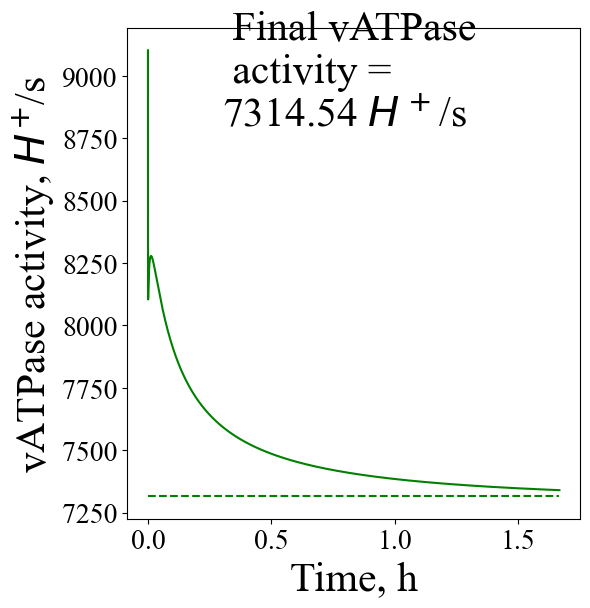

In [77]:
def plot_vATPase_work_Sp(t, solution, solution_stat, save_name, psi_arr, psi_arr_stat):
    t = t/3600
    plt.figure(figsize=(6,6), dpi=100)
    v_arr = np.vectorize(J_v)(solution[:, 2], psi_arr)
    v_arr_stat = J_v(solution_stat[:, 2][-1], psi_arr_stat[-1])
    plt.plot(t, v_arr, 'g', label='J_v$(t)$')
    plt.ylabel(r'vATPase activity, $H^{+}$/s', fontsize=30)
    plt.xlabel('Time, h', fontsize=30)
    plt.xticks(fontsize=20)
    plt.hlines(v_arr_stat, t[0], t[-1], linestyle='--', color='g', label='J_v$(t_{stat})$')
    plt.yticks(fontsize=20)
    plt.tight_layout()
    plt.text(0.3, 8800, ' Final vATPase \n activity = \n'  + str(round(v_arr_stat, 2)) + r' $H^+$/s', fontsize=30)
    plt.savefig('figs_TMEM165/' + save_name + '_JV.png', dpi=300)
    plt.show()

plot_vATPase_work_Sp(tspan, solution, solution_stat, 'Sp', psi_arr, psi_arr_stat)

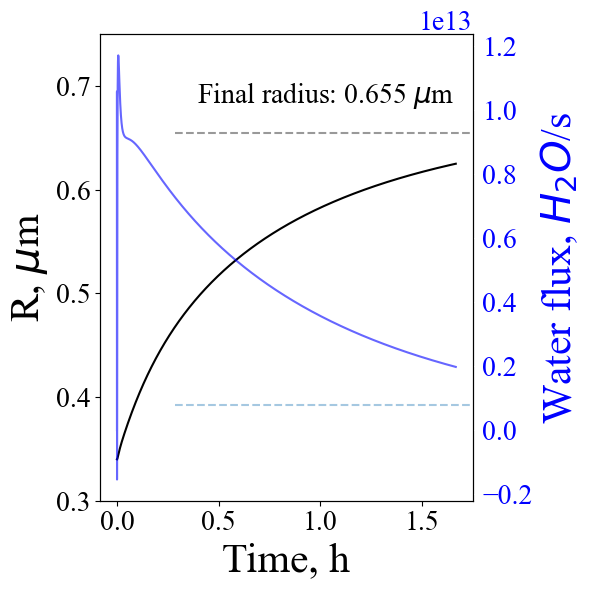

In [78]:
plot_solution_R(tspan, solution, solution_stat, V_arr, V_arr_stat, J_w_arr, J_w_arr_stat, R_text=.9, swelling=0,
                set_Rlim = 1, Rlim = [0.3, 0.75], save=True, save_name='Sp')

# Maturatuion

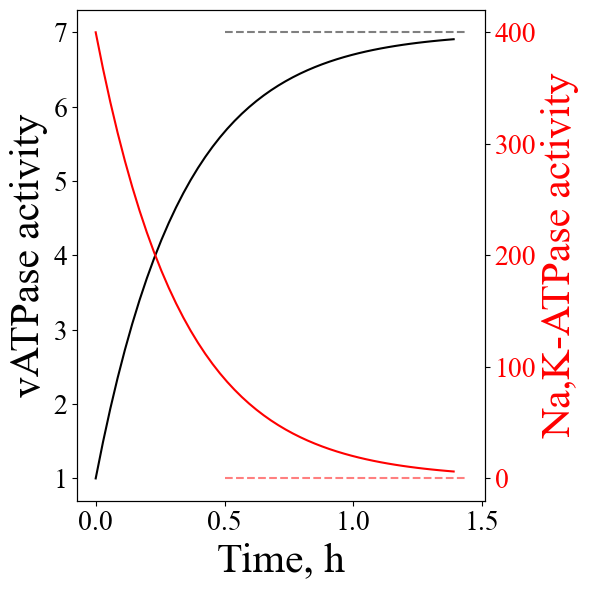

In [79]:
def N_VATP_plot(t):
    N_VATP_end = 7
    N_VATP_start = 1

    t_end = 6000
    if t<=t_end:
        N_VATP = (N_VATP_end - N_VATP_start)*(1-np.exp(-t*5/t_end)) + N_VATP_start
    else:
        N_VATP = N_VATP_end

    return N_VATP

def N_NKA_plot(t):
#     N_NKA_end = 13000
    N_NKA_end=0
    N_NKA_start = 40000
    t_end = 6000
    if t<=t_end:
        N_NKA = (N_NKA_end - N_NKA_start)*(1-np.exp(-t*5/t_end)) + N_NKA_start
    else:
        N_NKA = N_NKA_end

    return N_NKA

def N_TPC_plot(t):
    N_TPC_end = 10
    N_TPC_start = 100
    t_end = 6000
    if t<=t_end:
        N_TPC = (N_TPC_end - N_TPC_start)*(1-np.exp(-t*5/t_end)) + N_TPC_start
    else:
        N_TPC = N_TPC_end

    return N_TPC


t_ar = np.linspace(0, 5000)

fig, ax1 = plt.subplots(figsize=(6, 6), dpi=100)
ax1.plot(t_ar/3600, np.vectorize(N_VATP_plot)(t_ar), 'black')
ax1.hlines(7, 0.5, 5000/3600+0.05, color='black', clip_on=False, linestyle='dashed', alpha=0.5)

ax2 = ax1.twinx()

ax2.plot(t_ar/3600, np.vectorize(N_NKA_plot)(t_ar)/100, 'red')
ax2.tick_params(axis='y', colors='black', labelcolor='red')
ax2.hlines(0, 0.5, 5000/3600+0.05, color='red',clip_on=False, linestyle='dashed', alpha=0.5)
ax1.set_xlabel('Time, h', fontsize=30)
ax1.set_ylabel('vATPase activity', fontsize=30, color='black')
ax2.set_ylabel('Na,K-ATPase activity', fontsize=30, color='red')

from matplotlib.ticker import ScalarFormatter

sf = ScalarFormatter()
sf.set_powerlimits((-6, 4))
ax2.yaxis.set_major_formatter(sf)

plt.tight_layout()
plt.savefig('figs_TMEM165/maturation_NKA_vATP.png', dpi = 300)




In [80]:
init_R_endosome = 0.35
init_pH_endosome = 5.8
init_H_endosome = np.power(10, -init_pH_endosome)
init_K_endosome = 0.04
init_Na_endosome = 0.05
init_Cl_endosome = 0.06
init_Ca_T_endosome = 0.006
init_Ca_F_endosome = 0.0006
init_V_endosome = (4/3*3.1416*init_R_endosome**3*1e-12)/1000
B = init_K_endosome+init_Na_endosome+init_H_endosome-init_Cl_endosome  + init_Ca_T_endosome*2 - cap/F/init_V_endosome*(psi_in - psi_out)

In [81]:
def derivatives_mat(X, t):
    '''
    compute derfivatives of X wrt time
    '''
    Aeff, NH, pH, NK, NNa, NCl, NCa_T, NCa_F, R = X

    N_VATP_end = 7
    N_VATP_start = 1
    N_TPC_end = 10
    N_TPC_start = 100
    k_times = 4

    N_NKA_end = 0
    N_NKA_start = 50000
    t_end = 4000


    if t<=t_end:
        N_VATP = (N_VATP_end - N_VATP_start)*(1-np.exp(-t*5/t_end)) + N_VATP_start
        N_NKA = (N_NKA_end - N_NKA_start)*(1-np.exp(-t*5/t_end)) + N_NKA_start
        N_TPC = (N_TPC_end - N_TPC_start)*(1 - np.exp(-t*5/t_end)) + N_TPC_start
    else:
        N_NKA = N_NKA_end
        N_VATP = N_VATP_end
        N_TPC = N_TPC_start


    N_CAX = 16
    p = 3.88e-12

    P_Ca = 0        #[ion*cm/s]Pw
    P_Cl = 1.2e-5       #[ion*cm/s]
    P_H = 6e-05      #[ion*cm/s]
    P_K = 7.1e-7      #[ion*cm/s]
    P_Na = 9.6e-7      #[ion*cm/s]
    Pw = 0.054e-2


    pure_basefication = 0


     
    
    V = (4/3*3.1416*abs(R)**3*1e-12)/1000
    S = 4*3.1416*abs(R)**2*1e-8


    #Luminal Concentrations
    H = NH/V/NA
    K = NK/V/NA
    Na = NNa/V/NA
    Cl = NCl/V/NA
    Ca_F = NCa_F/V/NA
    Ca_T = NCa_T/V/NA
    r = Ca_F/Ca_T

    
    
    #membrane potential
#     psi = (F/cap)*init_V*(H + K + Na - Cl + 2*Ca_T - B)
    psi = (F/cap)*(V*(H + K + Na - Cl + 2*Ca_T) - B*init_V)


#      Modified Cytoplasmic Surface Concentrations
    pH_C0   = (pH_C+psi_out/(RTF*2.3))
    K_C0    = K_C*exp(-psi_out/RTF)
    Na_C0   = Na_C*exp(-psi_out/RTF) 
    Cl_C0   = Cl_C*exp(psi_out/RTF) 
    Ca_F_C0 = Ca_C*exp(-2*psi_out/RTF) 
    
#     Modified Luminal Surface Concentrations
    pH_L0   = (pH+psi_in/(RTF*2.3))
    K_L0    = K*exp(-psi_in/RTF)
    Na_L0   = Na*exp(-psi_in/RTF) 
    Cl_L0   = Cl*exp(psi_in/RTF) 
    Ca_F_L0 = Ca_F*exp(-2*psi_in/RTF) 

    delta_pH    = pH_C0-pH_L0;  

#     Treatment of singular terms for passive ion flux
    if (abs(psi) > 300):
        psi = np.sign(psi)*300
    if (abs(psi) > 0.01):
        gg      =  psi / (1 - exp (- psi / RTF)) / RTF
        gg_Ca   = 2*psi/(1-exp(-2*psi/RTF))/RTF

    else: 
        gg      =  1 / 1 - (psi / RTF)/2 + (psi / RTF)**2/6 - (psi / RTF)**3 / 24 + (psi / RTF) ** 4 / 120
        gg_Ca   = 1/(1 - (psi/RTF) + (2/3)*(psi/RTF)**2 - (1/3)*(psi/RTF)**3 +(2/15)*(psi/RTF)**4)
        

    # vAPTase
    J_VATPASE  = N_VATP * J_v(pH, psi)


        # ClC-7 Antiporter {H out, Cl in}
    CLC_mu      = (CLC_H + CLC_Cl)*psi + RTF*(CLC_H*2.3*delta_pH + CLC_Cl*np.log(Cl_C0/Cl_L0))
    
    #     Switching function   
    x = 0.5 + 0.5*np.tanh((CLC_mu + 250)/75); 
    # Activity
    A = 0.3*x + 1.5E-5*(1-x)*CLC_mu**2;
    
    if (A < Aeff):
        tau = tau_deact
    else:
        tau = tau_act
        
    J_CLC    = N_CLC*Aeff*CLC_mu 
    
    
#      CAX Antiporter {H out, Ca in} [mV, ion/s]
 
    
    xh = 6.7e3*exp(-0.9*pH) - 15
    k = 11.3*pH**2 - 116.5*pH + 325.3
    P_TPC = 1/(1+exp((xh-psi)/k))
    J_TPC = N_TPC*P_TPC*S*(Na_C0*exp(-psi/RTF)-Na_L0)*gg*NA/1000
    
    
#      Passive flux [ion/s]
    J_H = P_H*S*(10**(-pH_C0)*exp(-psi/RTF)-10**(-pH_L0))*gg*NA/1000
    J_K = P_K*S*(K_C0*exp(-psi/RTF)-K_L0)*gg*NA/1000
    J_Na = P_Na*S*(Na_C0*exp(-psi/RTF)-Na_L0)*gg*NA/1000

    # J_K = P_K*S*((K_C0+Na_C0)*exp(-psi/RTF)-(K_L0+Na_L0))*gg*NA/1000
    # J_Na = P_Na*S*((Na_C0+K_C0)*exp(-psi/RTF)-(K_L0+Na_L0))*gg*NA/1000
    J_Cl_unc = P_Cl*S*(Cl_C0-Cl_L0*exp(-psi/RTF))*gg*NA/1000
    J_Ca = P_Ca*S*(Ca_F_C0*exp(-2*psi/RTF)-Ca_F_L0)*gg_Ca*NA/1000
    


    
    #water flux
    J_w = Pw*S*(oh*10**(-pH) + ok*K + ona*Na + ocl*Cl + Q/V - Oc)
    
#     TRPML1 channel
    y = 0.5 - 0.5*np.tanh(psi + 40)
    P_trpml1 = p*(y*abs(psi) + (1-y)*(abs (psi + 40)**3)/(pH_L0**q))
    J_Ca_trpml1 = P_trpml1*S*(Ca_F_C0*exp(-2*psi/RTF)-Ca_F_L0)*gg_Ca*NA/1000

    J_vNa = interpolate_flux(K=K, Na = Na, Psi = psi, flux_psi = naflux_psi)
    J_vK = interpolate_flux(K=K, Na = Na, Psi = psi, flux_psi = kflux_psi)


    J_Ca_TMEM165 = S*(10**(-pH_C0)*exp(-psi/RTF)-10**(-pH_L0))*gg*NA/1000-2*((TMEM165_H - 2*TMEM165_Ca)*psi + RTF*(TMEM165_Ca/2*np.log(Ca_F_L0/Ca_F_C0)))*1e6
    N_TMEM165 = 0.0000035*2

    
    dxdt = [(1/tau)*(A - Aeff)/k_times,
        (J_H + (J_VATPASE) - (CLC_H*J_CLC) + (TMEM165_H*J_Ca_TMEM165*N_TMEM165) - pure_basefication)/k_times, 
           (-(J_H + (J_VATPASE) - (CLC_H*J_CLC) + (TMEM165_H*J_Ca_TMEM165*N_TMEM165) - pure_basefication)/V/NA)/beta_pH/k_times,
           (J_K + N_NKA*J_vK)/k_times,
           (J_Na + N_NKA*J_vNa + J_TPC)/k_times,
           (J_Cl_unc + (CLC_Cl*J_CLC))/k_times,
           (J_Ca - TMEM165_Ca*J_Ca_TMEM165*N_TMEM165 + J_Ca_trpml1)/k_times,
           (J_Ca - TMEM165_Ca*J_Ca_TMEM165*N_TMEM165 + J_Ca_trpml1)*r/k_times, 
           J_w/(1000*55)/(4*np.pi*(R/1e5)**2)*1e5/k_times]

    return dxdt

In [82]:
init_NH = init_H_endosome*init_V_endosome*NA;      #[ions]
init_NK = init_K_endosome*init_V_endosome*NA;       
init_NNa = init_Na_endosome*init_V_endosome*NA;    
init_NCl = init_Cl_endosome*init_V_endosome*NA;     
init_NCa_T = init_Ca_T_endosome*init_V_endosome*NA; 
init_NCa_F = init_Ca_F_endosome*init_V_endosome*NA; 

X0_mat = [init_Aeff, init_NH, init_pH_endosome, init_NK, init_NNa, init_NCl, init_NCa_T, init_NCa_F, init_R_endosome]

In [83]:
tspan = np.arange(0, 5000, 1e-2)
solution = odeint(derivatives_mat, X0_mat, tspan)

tspan_stat = np.arange(0, 40000, 1e-2)
solution_stat = odeint(derivatives_mat, X0_mat, tspan_stat)

In [84]:
V_arr = V_arr_def(solution)
psi_arr = Psi_arr_def(solution, V_arr)
J_w_arr = J_w_arr_def(solution, V_arr)

V_arr_stat = V_arr_def(solution_stat)
psi_arr_stat = Psi_arr_def(solution_stat, V_arr_stat)
J_w_arr_stat = J_w_arr_def(solution_stat, V_arr_stat)

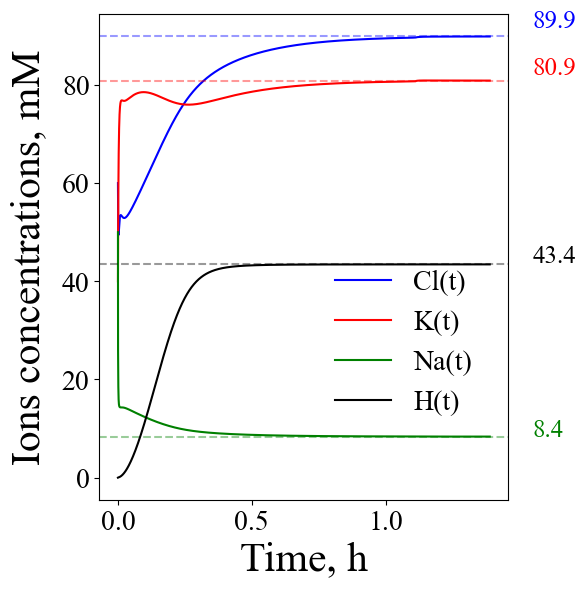

In [85]:
plot_solution_concentrations(tspan, solution, solution_stat=solution_stat, V_arr=V_arr, V_arr_stat=V_arr_stat,
                             x_text=1.55, save=True, save_name='maturation', legend_loc=[0.55, 0.15], show_H=True)


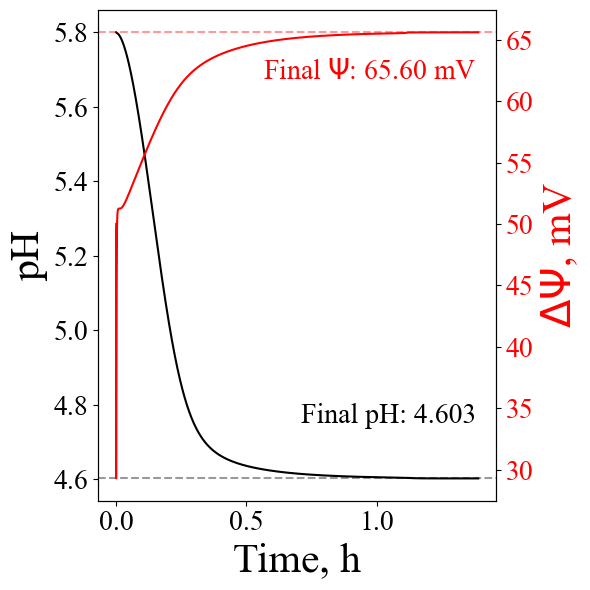

In [86]:
plot_solution_pH_psi(tspan, solution, solution_stat, psi_arr, psi_arr_stat[-1], psi_text=0.9, pH_text=0.2,
                     set_pHlim=False, pHlim=[4.6, 5.25], save=True, save_name='Maturation')

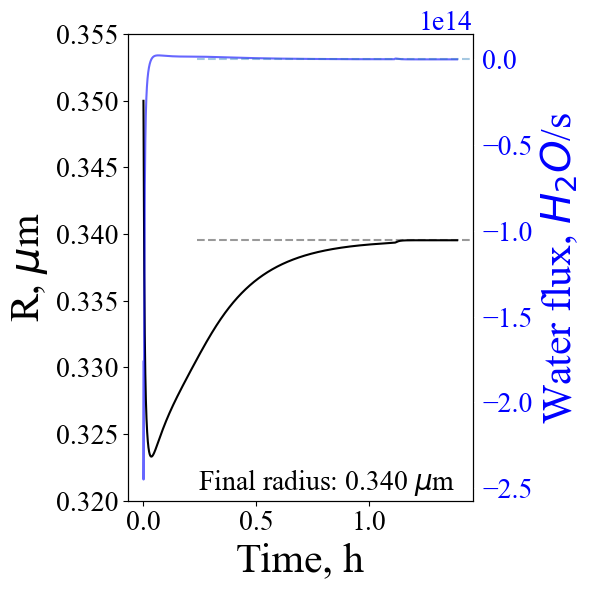

In [87]:
plot_solution_R(tspan, solution, solution_stat, V_arr, V_arr_stat, J_w_arr, J_w_arr_stat, R_text=0.07, swelling=0,
                set_Rlim = True, Rlim = [0.32, 0.355], save=True, save_name='mat')